# HANK model with energy: Alternative specifications

Selma Malmberg & François Langot

January 2025

The aim of this notebook is to solve a HANK model with energy, calibrate it using French data and build counterfactual policies in reaction of the recent energy crisis and study the sensitivity to the energy market specification.

### Table of content
0. [Set up](#0-setup)
1. [Benchmark model ($\nu=1$)](#1-Bench)
2. [With elastic energy supply ($\nu\in\{0.9, 0.75\}$)](#2-Elas)
3. [Trade balance alternatives](#3-TB)

<a id="0-setup"></a>
## 0 Set up

In [1]:
# Python libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import beta, invgamma, norm
import statsmodels.api as sm
import scipy.optimize as opt
import string

In [2]:
# Auclert et al's toolbox
import sequence_jacobian as ssj

In [3]:
from TOOLS.Auclert_Toolbox.plots import plot_impulses
from TOOLS.Auclert_Toolbox.routines import back_out_shocks

In [4]:
# Selma's codes
import TOOLS.utilities as util
import TOOLS.IRFs as irf
import TOOLS.forecasts as fcst
import TOOLS.estimation as est

Set the following variables to True or False:
- `save_fig`: True to save the charts
- `estimation_flag`: True if you wish to run the estimation

In [5]:
save_fig         = True # True
estimation_flag  = False # True

In [6]:
# For LaTeX font on figures
plt.rc('text', usetex=False)
plt.rc('font', family='serif')

<a id="1-Bench"></a>
## 1 Benchmark model ($\nu=1$)

1. [Household block](#1a-HA)
2. [Steady state](#1b-SS)
3. [Dynamics](#1c-Dyn)
4. [Shocks](#1d-Shock)

<a id="1a-HA"></a>
### 1 Household block

In [7]:
# Import the households' block
from CepreHANKv1 import household

In [8]:
print('Inputs: ', *household.inputs)
print('Outputs: ', *household.outputs)

Inputs:  beta eis cbar pFE_HA w r taul tauc L YFE YF Div Tax Trans Subv Subv1 Subv2 rho_s sigma_s nS amin amax nA
Outputs:  A C C_TOT N NS INC CFE CH C_0 C_1 C_2 C_3 C_4 C_5 C_6 CTOT_0 CTOT_1 CTOT_2 CTOT_3 CTOT_4 CTOT_5 CTOT_6 A_0 A_1 A_2 A_3 A_4 A_5 A_6 N_0 N_1 N_2 N_3 N_4 N_5 N_6 NS_0 NS_1 NS_2 NS_3 NS_4 NS_5 NS_6 INC_0 INC_1 INC_2 INC_3 INC_4 INC_5 INC_6 CFE_0 CFE_1 CFE_2 CFE_3 CFE_4 CFE_5 CFE_6 CH_0 CH_1 CH_2 CH_3 CH_4 CH_5 CH_6


<a id="1b-SS"></a>
### 2 Steady state

In [9]:
calibration = {# Targets
               'r': 0.005, 'L': 1.0, 
               'se': 0.087, 'sce': (0.087 / 2) * 0.4,
               # Fiscal policy
               'B_b': 4, 'B_g': 0.2, 'B_t': 0.25, 
               'sH': 0, 'sF': 1e-50,
               'tauc': 0.2, 'taul': 0.2, 'tau1': 0.1, 'χl': 1e-10, 'χc': 1e-10,
               # NKPCs
               'kappa': 0.95, 'mu': 1.2, 'kappaw': 0.1, 'muw': 1.1,
               # Utility
               'eis': 1, 'frisch': 0.5,
               # Production
               'alpphaE': 0.025, 'etaE': 0.5, 
               'share': 0.5,
               # Taylor rule
               'phi': 1.2, 'phiy': 0.0, 'rhor': 0.85,
               # Grids
               'nA': 500, 'amin': 0, 'amax': 300,
               'nS': 7, 'rho_s': 0.966, 'sigma_s': 0.5
}

unknowns_ss = {'beta': 0.9922005057100952, 'vphi': 0.6348672836874902, 'Tax': 0.18375887656711004}
targets_ss  = {'asset_mkt': 0.0, 'labour_mkt': 0.0, 'balanced_bud': 0.0}

In [10]:
# Solve the steady-state
from CepreHANKv1 import model_ss, market_clearing_ss
# model_ss.solve_steady_state_options['verbose'] = True
ss = model_ss.solve_steady_state(calibration=calibration, unknowns=unknowns_ss, targets=targets_ss)

<a id="1c-Dyn"></a>

### 3 Dynamics

In [11]:
from CepreHANKv1 import subsidy, firm, energy_policy, nkpc, inflation, union, wage, mkt_clearing, household, definitions, estim_eq

In [12]:
@ssj.solved(unknowns={'i': 0.005}, targets=['i_res'])
def monetary(i, Y, pi, phi, phiy, rhor, i_shock):
    i_res = (1-rhor) * (ss['r'] + phi * pi + phiy * (Y - Y.ss) ) + rhor * i(-1) + i_shock - i 
    r     = (1 + i(-1))/(1 + pi) - 1
    return i_res, r

In [13]:
@ssj.simple
def fiscal(B, tau1, w, pFE, L, r, Dep, tauc, taul, Capprox, cbar, TransEXO, TaxEXO): 
    Trans    = TransEXO + ss['Trans'] - tau1 * ( B(-1)/B.ss -1 ) 
    Tax      = TaxEXO + ss['Tax']
    Recettes = Tax + taul * w * L + tauc * Capprox + tauc * pFE * cbar
    debt_res = (1 + r) * B(-1) - Recettes + (Dep + Trans) - B
    return debt_res, Trans, Tax, Recettes

In [14]:
unknowns   = ['pi', 'w', 'Y', 'Capprox', 'B']
targets    = ['nkpc_res', 'asset_mkt', 'labour_mkt', 'conso', 'debt_res']
block_list = [subsidy, firm, energy_policy, monetary, fiscal, nkpc, inflation, union, wage, mkt_clearing, definitions, household]
model      = ssj.create_model(block_list, name='CepreHANK')

In [15]:

# dpFE_HA  = irf.shock_generator(ss, 'pFE_HA', rho=.8, p=80/100, T=T, truncated_T=truncated_T, display=False).reshape(T)
# dsubv    = dpFE - dpFE_HA


 <a id="2-Elas"></a>
## 2 With elastic energy supply ($\nu\in\{0.9, 0.75\}$)

1. [$\nu=0.9$](#2a-0.9)
2. [$\nu=0.75$](#2b-0.75)
3. [IRFs](#2d-IRFs)

<a id="2a-0.9"></a>
### 1 Model with $\nu=0.9$

##### Steady state.

In [16]:
calibration_E1 = calibration.copy()
calibration_E1.update({'nu': 0.9, 'paramB': 1.0})

In [17]:
@ssj.simple
def equations_ss_E(share, nu, paramB, r, B_b, B_g, B_t, L, mu, se, sce, alpphaE, etaE, tauc, sF):
    alpphaf = alpphaE * (1/share - 1) / (1-alpphaE)
    
    Z    = 1
    i    = r
    Br   = B_b
    mc   = 1/mu
    mcF  = mc
    pF   = mcF
    pFE  = (1/Z) * ( ((se)/(alpphaE + alpphaf*(1-alpphaE))) * (mc**(-etaE)) )**(1/(1-etaE))
    pFE_HA = pFE
    pH   = ( (1/(1-alpphaE)) * ( (mcF**(1-etaE)) - (alpphaE * (pFE)**(1-etaE)) ) )**(1/(1-etaE))
    mcH  = pH
    w    = ( (1/(1-alpphaf)) * ( ((Z*mcH)**(1-etaE)) - (alpphaf * (pFE)**(1-etaE)) ) )**(1/(1-etaE))
    YH   = (L / (1-alpphaf)) * (Z**(1-etaE)) * (w/mcH)**(etaE)
    E    = alpphaf * YH * (pFE/mcH)**(-etaE) * Z**(etaE-1)
    YF   = (YH / (1-alpphaE)) * (pH/mcF)**etaE
    Y    = YF
    YFE  = alpphaE * YF * (pFE/mcF)**(-etaE)
    E    = alpphaf * (1-alpphaE) * (pFE / pF)**(-etaE) * Y
    cbar = sce * Y / pFE
    Edemand = E + YFE
    Esupply   = (Edemand / paramB)**(1 / nu)
    pFE_tilde = pFE * paramB * nu * Esupply**(nu - 1)
    incomp = pFE * cbar
    Div  = Y * (1 - mc)
    DivE = 0
    B    = B_b * Y 
    G    = B_g * Y
    Trans= B_t * Y
    Subv = 0
    Subv1 = 0
    Subv2 = 0
    pi = 0
    piw = 0
    piH = 0
    piF = 0
    piFE = 0
    subv = 0
    bouclier = (pFE - pFE_HA) * YFE + (pFE - pFE_HA) * (1 + tauc) * cbar + sF * pFE * E
    bouclier_Y = bouclier / Y
    bouclier_Yss = bouclier / Y
    Dep  = G + Subv + Subv1 + Subv2 + bouclier
    TransEXO = 0
    TaxEXO   = 0
    adj_p = 0
    i_shock = 0
    return alpphaf, Z, i, Br, mc, mcF, pF, pFE, pFE_HA, pFE_tilde, pH, mcH, w, YH, E, YF, Y, YFE, cbar, incomp, Esupply, Edemand, Div, DivE, B, G, Trans, Subv, Subv1, Subv2, pi, piw, piH, piF, piFE, subv, bouclier, bouclier_Y, bouclier_Yss, Dep, TransEXO, TaxEXO, adj_p, i_shock

In [18]:
@ssj.simple
def market_clearing_ss_E(A, B, paramB, nu, cbar, YFE, E, vphi, w, taul, tauc, C, L, eis, frisch, muw, Y, G, pFE, pFE_tilde, Tax, r, B_b, B_g, B_t, Edemand):
    asset_mkt    = A - B
    energy_mkt   = E + YFE - paramB**(1/(1-nu)) * (nu * pFE / pFE_tilde)**(nu/(1-nu))
    labour_mkt   = vphi - w * ((1 - taul)/(1 + tauc)) * (C**(-1/eis)) * (L**(-1/frisch)) / muw
    homegood_mkt = Y - (C + pFE*cbar + G + pFE * Edemand)
    balanced_bud = taul * w * L + tauc * (C + pFE * cbar) + Tax - (r * B_b + B_g + B_t) * Y
    return asset_mkt, energy_mkt, labour_mkt, homegood_mkt, balanced_bud

In [19]:
from CepreHANKv1 import definitions_ss

model_ss_E = ssj.create_model(blocks=[household, equations_ss_E, definitions_ss, market_clearing_ss_E], name='CepreHANK with elastic energy supply steady-state')
# model_ss_E.solve_steady_state_options['verbose'] = True
ss_E1 = model_ss_E.solve_steady_state(calibration=calibration_E1, unknowns=unknowns_ss, targets=targets_ss)
ss['DivE'] = 0

#### Dynamics.

In [20]:
@ssj.solved(unknowns={'pFE': ss['pFE']}, targets=['energy_mkt'])
def firm_E(pFE, paramB, nu, Y, w, pi, alpphaE, alpphaf, etaE, mu, kappa, tauc, cbar, sF, Z, G, pFE_tilde, subv, Subv, Subv1, Subv2):   
    pFE_HA = pFE - subv
    
    pH  = (1/Z) * ( alpphaf*((1-sF)*pFE)**(1-etaE) + (1-alpphaf)*w**(1-etaE) )**(1/(1-etaE))
    pF  = ( alpphaE*(pFE_HA)**(1-etaE) + (1-alpphaE)*pH**(1-etaE) )**(1/(1-etaE))
    mcF = pF
    mcH = pH
    
    YH  = (1-alpphaE) * ( (pH/mcF)**(-etaE) ) * Y 
    YFE = alpphaE * ( (pFE_HA/mcF)**(-etaE) ) * Y
    L   = (1-alpphaf) * ( (w/mcH)**(-etaE) ) * YH * Z**(etaE-1)
    E   = alpphaf * ( ((1-sF)*pFE/mcH)**(-etaE) ) * YH * Z**(etaE-1)
    
    adj_p = Y * (((mu/(mu-1))/kappa)/2)*(pi**2)
    bouclier = (pFE - pFE_HA) * YFE + (pFE - pFE_HA) * (1 + tauc) * cbar + sF * pFE * E
    bouclier_Y = bouclier / Y
    bouclier_Yss = bouclier / Y.ss
    Dep   = bouclier + G + Subv + Subv1 + Subv2
    Div   = Y - pF * Y - adj_p
    Edemand = E + YFE
    Esupply = (pFE_tilde / (pFE * paramB * nu)) ** (1/(nu - 1))
    DivE  = 0
    energy_mkt = Edemand - paramB**(1/(1-nu)) * (nu * pFE / pFE_tilde)**(nu/(1-nu))
    return energy_mkt, pFE_HA, pH, pF, YH, E, bouclier, bouclier_Y, bouclier_Yss, Dep, L, YFE, Div, DivE, Edemand, Esupply, adj_p, mcF, mcH

In [21]:
@ssj.simple
def estim_eq(TransEXO, G, subv, pFE_tilde):
    TransEXO_out = TransEXO
    G_out = G
    subv_out = subv
    pFE_tilde_out = pFE_tilde
    return TransEXO_out, G_out, subv_out, pFE_tilde_out

In [22]:
@ssj.simple
def mkt_clearing_E(A, B, C, Capprox, G, Y, pFE, cbar, adj_p, Edemand):
    Br         = B / Y
    asset_mkt  = A - B
    homegood_mkt = Y - C - G - pFE * Edemand - pFE * cbar - adj_p
    conso      = Capprox - C
    incomp     = pFE * cbar
    return asset_mkt, homegood_mkt, Br, conso, incomp

In [23]:
unknowns_E   = ['pi', 'w', 'Y', 'Capprox', 'B']
targets_E    = ['nkpc_res', 'asset_mkt', 'labour_mkt', 'conso', 'debt_res']
block_list_E = [firm_E, monetary, fiscal, nkpc, union, wage, mkt_clearing_E, estim_eq, household]
model_E      = ssj.create_model(block_list_E, name='CepreHANK with energy dividends')

<a id="2b-0.75"></a>
### 2 Model with $\nu=0.75$

In [24]:
calibration_E2 = calibration.copy()
calibration_E2.update({'nu': 0.75, 'paramB': 1.0})

In [25]:
ss_E2 = model_ss_E.solve_steady_state(calibration=calibration_E2, unknowns=unknowns_ss, targets=targets_ss)

<a id="2d-IRFs"></a>
### 3 IRFs

$p_{FE}$ is exogenous when $\nu=1$ because $p_{FE}=\tilde{p}_{FE}$ $\Rightarrow$ shock $=dp_{FE}$

$\tilde{p}_{FE}$ is exogenous when $\nu<1$, but $p_{FE}$ is endogenous $\Rightarrow$ shock $=d\tilde{p}_{FE}$

The consumers pay $p_{FE}^{HA} = (1-s_H)p_{FE} = p_{FE} - subv$ $\Rightarrow$ The tariff shield shock is deduced from 
$$
dp_{FE}^{HA} = dp_{FE}-dsub~~\Rightarrow~~dsubv= dp_{FE}^{HA}-dp_{FE}
$$ 
where $dp_{FE}$ is exogenous if $\nu=1$ but endogenous if $nu<1$

In [26]:
T = 500
truncated_T = 30

In [27]:
var = ['pFE_HA', 'pi', 'i',
       'Y', 'E', 'L',
       'w', 'C', 'YFE']

var_names = ['Subsidized energy price', 'Inflation', 'Nominal interest rate',
             'Output', 'Energy input', 'Labor',
             'Real wage', 'Consumption', 'Household energy consumption'] 

#### Energy price shock.

In [28]:
dpFE           = irf.shock_generator(ss, 'pFE', rho=.8, p=100/100, T=T, truncated_T=truncated_T, display=False).reshape(T)
dpFE_tilde_E1  = irf.shock_generator(ss_E1, 'pFE_tilde', rho=.8, p=100/100, T=T, truncated_T=truncated_T, display=False).reshape(T)
dpFE_tilde_E2  = irf.shock_generator(ss_E2, 'pFE_tilde', rho=.8, p=100/100, T=T, truncated_T=truncated_T, display=False).reshape(T)

In [29]:
# Linear
irfs      = model.solve_impulse_linear(ss, unknowns=unknowns, targets=targets,
                                  inputs={'pFE': dpFE})
irfs_E1   = model_E.solve_impulse_linear(ss_E1, unknowns=unknowns_E, targets=targets_E,
                                  inputs={'pFE_tilde': dpFE_tilde_E1})
irfs_E2   = model_E.solve_impulse_linear(ss_E2, unknowns=unknowns_E, targets=targets_E,
                                  inputs={'pFE_tilde': dpFE_tilde_E2})

------ Figure 20a: Subsidized energy price ------


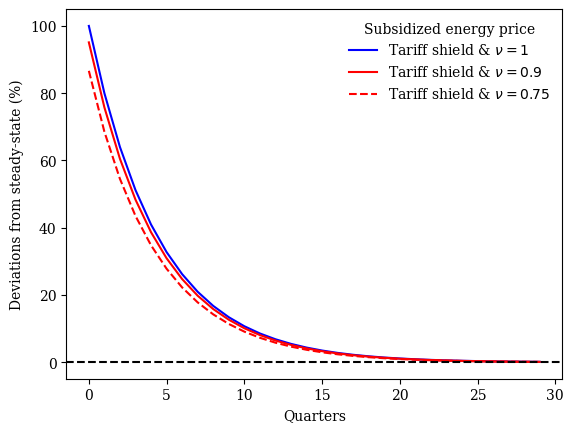

------ Figure 20b: Inflation ------


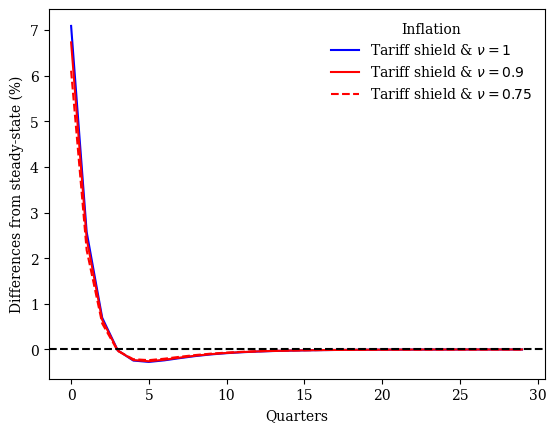

------ Figure 20c: Nominal interest rate ------


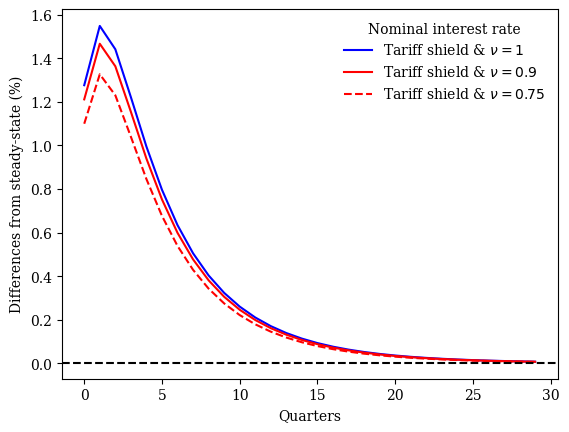

------ Figure 20d: Output ------


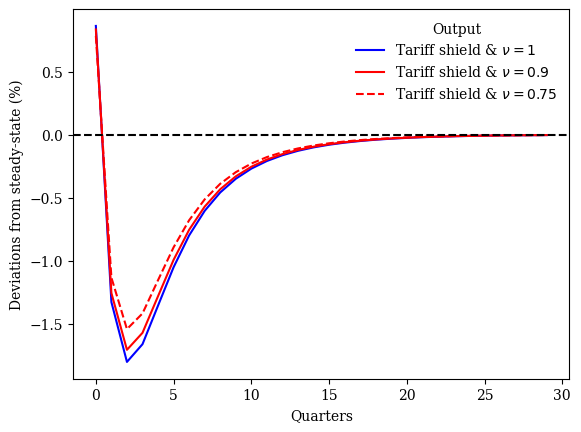

------ Figure 20e: Energy input ------


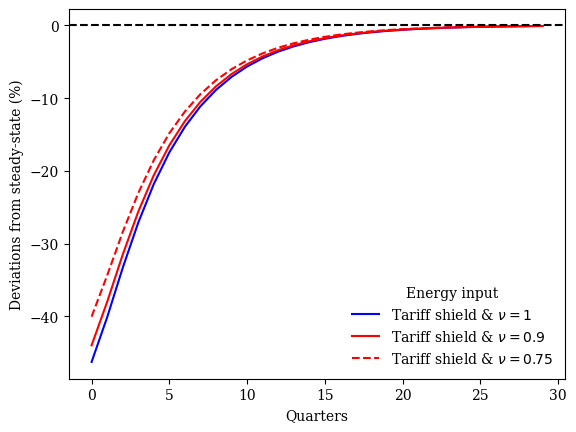

------ Figure 20f: Labor ------


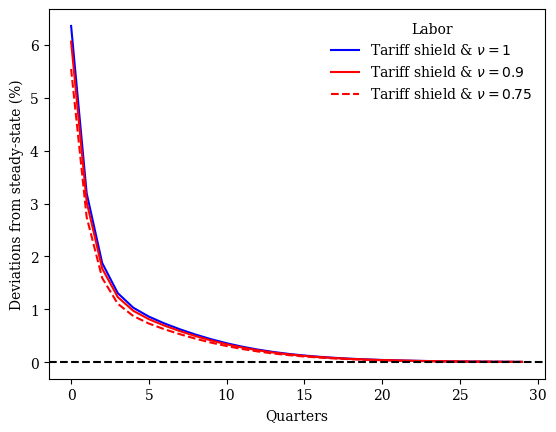

------ Figure 20g: Real wage ------


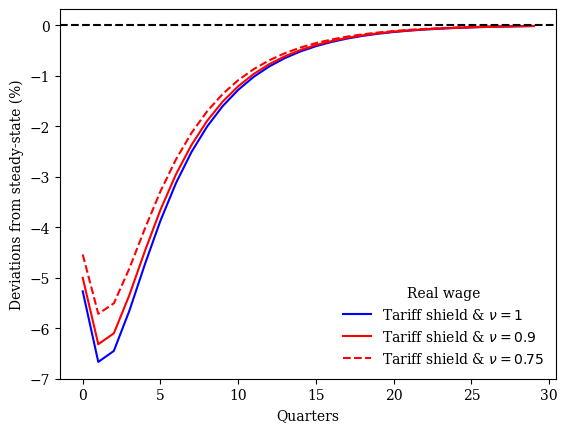

------ Figure 20h: Consumption ------


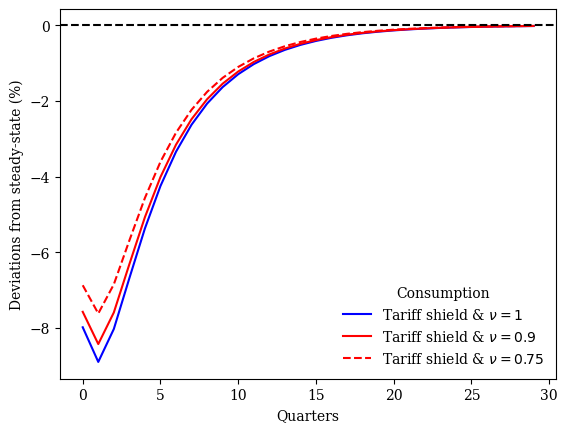

------ Figure 20i: Household energy consumption ------


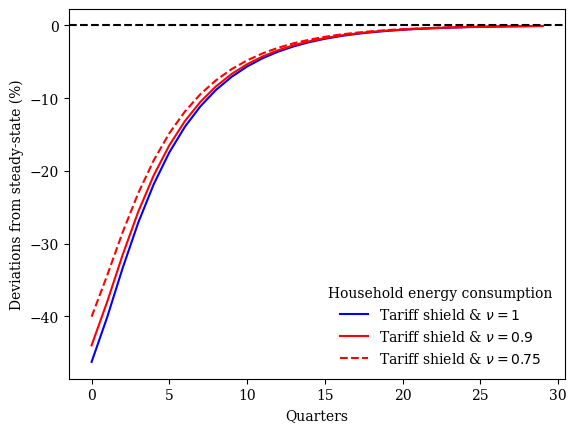

In [30]:
# Figure 20: IRFs (energy shock)
for i in range(len(var)):
    print('------ Figure 20'+string.ascii_lowercase[i]+': '+var_names[i]+' ------')
    if var[i] in ['pi', 'i', 'r']:
        plt.plot(100 * (irfs[var[i]])[:truncated_T], color='blue', label=r'Tariff shield & $\nu=1$')
        plt.plot(100 * (irfs_E1[var[i]])[:truncated_T], color='red', label=r'Tariff shield & $\nu=0.9$')
        plt.plot(100 * (irfs_E2[var[i]])[:truncated_T], color='red', linestyle='--', label=r'Tariff shield & $\nu=0.75$')
        plt.ylabel('Differences from steady-state (%)')
    else:
        plt.plot(100 * (irfs[var[i]] / ss[var[i]])[:truncated_T], color='blue', label=r'Tariff shield & $\nu=1$')
        plt.plot(100 * (irfs_E1[var[i]] / ss_E1[var[i]])[:truncated_T], color='red', label=r'Tariff shield & $\nu=0.9$')
        plt.plot(100 * (irfs_E2[var[i]] / ss_E2[var[i]])[:truncated_T], color='red', linestyle='--', label=r'Tariff shield & $\nu=0.75$')
        plt.ylabel('Deviations from steady-state (%)')
    plt.axhline(0, linestyle='--', color='black')
    plt.xlabel('Quarters')
    plt.legend(frameon=False, title=var_names[i])
    if save_fig:
        plt.savefig('Figures/Figure20'+string.ascii_lowercase[i]+'.eps', dpi=500)
    plt.show()

#### Tariff shield shock.

In [31]:
dpFE_HA  = irf.shock_generator(ss, 'pFE_HA', rho=.8, p=80/100, T=T, truncated_T=truncated_T, display=False).reshape(T)
dsubv    = dpFE - dpFE_HA

dpFE_HA_E1  = irf.shock_generator(ss_E1, 'pFE_HA', rho=.8, p=80/100, T=T, truncated_T=truncated_T, display=False).reshape(T)
dpFE_E1     = irf.shock_generator(ss_E1, 'pFE_tilde', rho=.8, p=80/100, T=T, truncated_T=truncated_T, display=False).reshape(T)
dsubv_E1    = dpFE_E1 - dpFE_HA_E1

dpFE_HA_E2  = irf.shock_generator(ss_E2, 'pFE_HA', rho=.8, p=80/100, T=T, truncated_T=truncated_T, display=False).reshape(T)
dpFE_E2     = irf.shock_generator(ss_E2, 'pFE_tilde', rho=.8, p=80/100, T=T, truncated_T=truncated_T, display=False).reshape(T)
dsubv_E2    = dpFE_E2 - dpFE_HA_E2


In [32]:
# Linear
irfs_ts      = model.solve_impulse_linear(ss, unknowns=unknowns, targets=targets,
                                  inputs={'subv': dsubv})
irfs_E1_ts   = model_E.solve_impulse_linear(ss_E1, unknowns=unknowns_E, targets=targets_E,
                                  inputs={'subv': dsubv_E1})
irfs_E2_ts   = model_E.solve_impulse_linear(ss_E2, unknowns=unknowns_E, targets=targets_E,
                                  inputs={'subv': dsubv_E2})

------ Figure 21a: Subsidized energy price ------


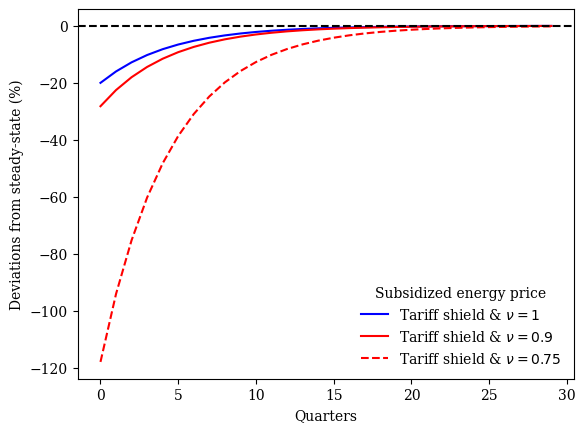

------ Figure 21b: Inflation ------


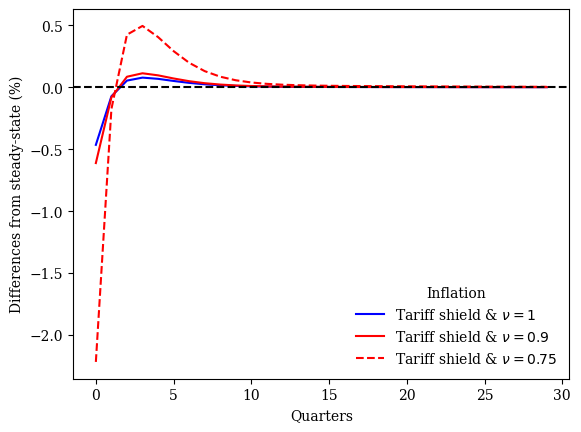

------ Figure 21c: Nominal interest rate ------


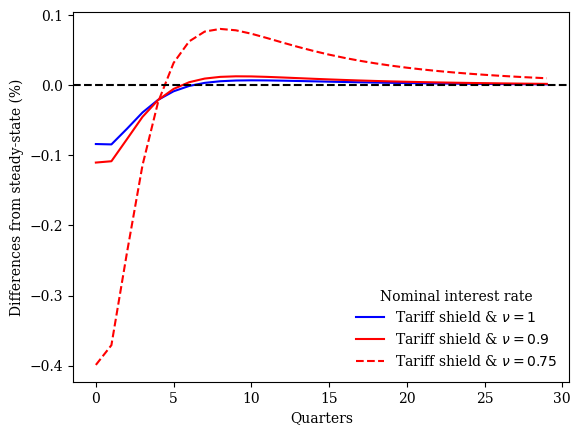

------ Figure 21d: Output ------


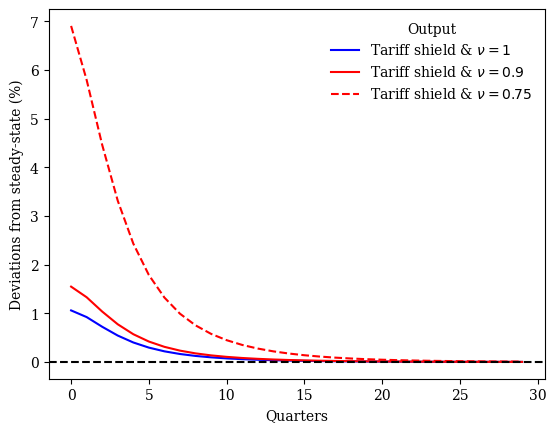

------ Figure 21e: Energy input ------


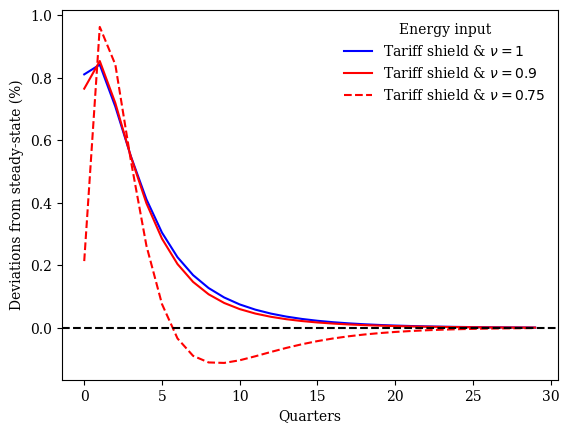

------ Figure 21f: Labor ------


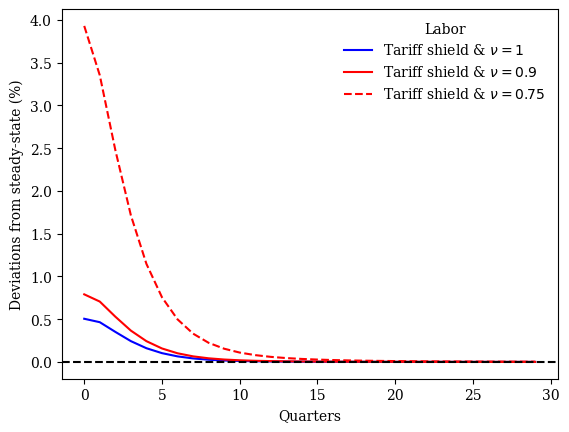

------ Figure 21g: Real wage ------


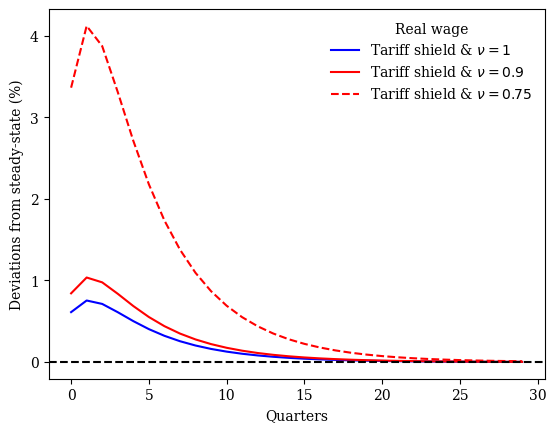

------ Figure 21h: Consumption ------


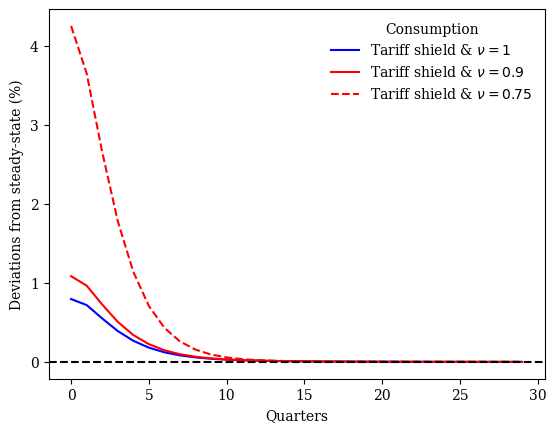

------ Figure 21i: Household energy consumption ------


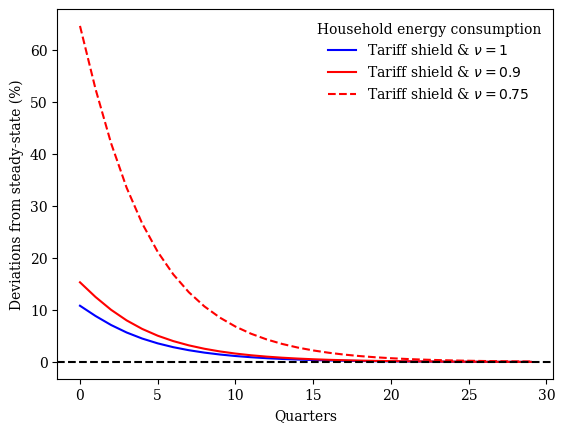

In [33]:
# Figure 21: IRFs (tariff shield shock)
for i in range(len(var)):
    print('------ Figure 21'+string.ascii_lowercase[i]+': '+var_names[i]+' ------')
    if var[i] in ['pi', 'i', 'r']:
        plt.plot(100 * (irfs_ts[var[i]])[:truncated_T], color='blue', label=r'Tariff shield & $\nu=1$')
        plt.plot(100 * (irfs_E1_ts[var[i]])[:truncated_T], color='red', label=r'Tariff shield & $\nu=0.9$')
        plt.plot(100 * (irfs_E2_ts[var[i]])[:truncated_T], color='red', linestyle='--', label=r'Tariff shield & $\nu=0.75$')
        plt.ylabel('Differences from steady-state (%)')
    else:
        plt.plot(100 * (irfs_ts[var[i]] / ss[var[i]])[:truncated_T], color='blue', label=r'Tariff shield & $\nu=1$')
        plt.plot(100 * (irfs_E1_ts[var[i]] / ss_E1[var[i]])[:truncated_T], color='red', label=r'Tariff shield & $\nu=0.9$')
        plt.plot(100 * (irfs_E2_ts[var[i]] / ss_E2[var[i]])[:truncated_T], color='red', linestyle='--', label=r'Tariff shield & $\nu=0.75$')
        plt.ylabel('Deviations from steady-state (%)')
    plt.axhline(0, linestyle='--', color='black')
    plt.xlabel('Quarters')
    plt.legend(frameon=False, title=var_names[i])
    if save_fig:
        plt.savefig('Figures/Figure21'+string.ascii_lowercase[i]+'.eps', dpi=500)
    plt.show()

#### Estimation.

In [34]:
# Import data from excel file
data_estim = pd.read_excel('esti_data.xlsx')
data_raw = data_estim.copy()

In [35]:
labels_estim = ['GDP', 'Price index', 'Energy prices', 'Transfers', 'Government spending', 'Debt-to-GDP ratio']
modvar_estim = ['Y', 'pi', 'pFE', 'TransEXO', 'G', 'Br']
data_estim.columns = ['t'] + modvar_estim

# Build indexes worth 100 in 4Q2019
ref = data_estim['t'][data_estim['t'] == pd.to_datetime('2019-10-01')].index[0]
for elem in modvar_estim:
    if elem != 'Br':
        data_estim[elem] = 100 * data_estim[elem] / data_estim[elem].loc[ref]

###### Stationarise the data

In [36]:
def remove_trend(data, g=None, verbose=False):
    """Remove the trend of a series.
    Inputs
    --------------
    data          : series to detrend
    g             : float, growth rate of the trend. If None it is estimated via OLS
    verbose       : bool, set True to display
    
    Ouptuts
    --------------
    results.resid : detrended series with estimated g
    g             : estimated growth rate of the trend
    data_stat     : detrended series with given g
    """
    if g is not None:
        T = len(data)
        data_stat = data / (data.iloc[0] * (1 + g) ** np.arange(T)) - 1
        return data_stat
    
    y = np.array(np.log(np.array(data)))
    X = np.array([i for i in range(1, len(data)+1)])
    X = sm.add_constant(X)
    model = sm.OLS(y, X)
    results = model.fit()
    if verbose:
        print(results.summary())
    g = results.params[1]
    return results.resid, g, results

In [37]:
def AR_estim(data, verbose=False):
    y = data[1:]
    X = data[0:-1]
    X = sm.add_constant(X)
    model = sm.OLS(y, X)
    results = model.fit()
    if verbose:
        print(results.summary())
    const = results.params[0]
    ρ = results.params[1]
    std_ρ = results.bse[1]
    σ = np.std(results.resid)
    std_σ = np.max(results.resid)/3 # max is approx 3 std away from the mean
    return {'ρ': ρ, 'std ρ': std_ρ, 'σ': σ, 'std σ': std_σ, 'R2': results.rsquared_adj}

In [38]:
# Data treatment and estimation of the parameters of the known/exogenous shocks
AR_est = {}
trend  = {}
hist_mean = {}
full_results = {}
data_estim_stat = data_estim.copy()

# Select the data from 2Q1995 to 4Q2019 for the estimation
data_estim_stat = data_estim_stat[data_estim_stat['t'].dt.year <= 2019]

# Remove trends and estimate the AR(1) when possible
for elem in ['Y', 'G', 'TransEXO', 'pFE']:
    res, t, full = remove_trend(data_estim_stat[elem])
    full_results[elem]  = full
    trend[elem] = t
    if elem in ['pFE', 'G', 'TransEXO']:
        AR_est[elem] = AR_estim(res)
    if elem in ['Y', 'G', 'TransEXO']: # Detrended
        if elem == 'TransEXO':
            data_estim_stat[elem] = res * ss['Trans']
        else:
            data_estim_stat[elem] = res * ss[elem]

# Inflation rates
data_estim_stat['pi']     = data_estim['pi'].pct_change()
data_estim_stat           = data_estim_stat.dropna()

# Remove the historical means
for elem in ['pFE', 'Br', 'pi']:
    hist_mean[elem] = np.mean(data_estim_stat[elem])
    data_estim_stat[elem] = (data_estim_stat[elem] - np.mean(data_estim_stat[elem])) / np.mean(data_estim_stat[elem])
    if elem == 'pFE':
        data_estim_stat[elem] = data_estim_stat[elem] * ss[elem]

###### Maximum likelihood estimation
This is just a trial to get a starting point for the Bayesian estimation.

In [39]:
data_estim_stat = data_estim_stat.rename(columns = {'pFE': 'pFE_tilde'})

In [40]:
# Shocks to estimate
exogenous_estim =  ['mu', 'beta', 'TaxEXO', 'TransEXO', 'G', 'pFE_tilde']
inout   = ['TransEXO', 'G', 'pFE_tilde']
legends = {'mu': 'μ', 'beta': 'β', 'TaxEXO': 'τres', 'pFE_tilde': 'pFE_tilde', 'TransEXO': 'Trans', 'G': 'G'}

leg = [r"$\rho_{}$".format(legends[e]) for e in exogenous_estim] + [r'$\sigma_{}$'.format(legends[e]) for e in exogenous_estim]
n_estim = len(exogenous_estim)
T_estim = len(data_estim_stat)

# Variables used in the model
var_estim = ['Y', 'pi', 'Br', 'TransEXO', 'G', 'pFE_tilde'] 

# Data for the estimation
Y_estim = np.array(data_estim_stat[var_estim])

In [41]:
%time G_estim_E1 = model_E.solve_jacobian(ss_E1, unknowns=unknowns, targets=targets, inputs=exogenous_estim+['subv', 'Subv', 'Subv2', 'χc', 'χl', 'i_shock'], T=T_estim)
%time G_estim_E2 = model_E.solve_jacobian(ss_E2, unknowns=unknowns, targets=targets, inputs=exogenous_estim+['subv', 'Subv', 'Subv2', 'χc', 'χl', 'i_shock'], T=T_estim)

CPU times: user 5.57 s, sys: 3.36 s, total: 8.93 s
Wall time: 1.38 s
CPU times: user 5.65 s, sys: 3.08 s, total: 8.73 s
Wall time: 1.29 s


In [42]:
def estimation(f, x0, legends=leg, method='Powell', verbose=False, bounds=None):
    """Solves and display the results of the maximum likelihood estimation."""
    if method == 'downhill':
        print('Method:', 'downhill simplex')
        sol_val = opt.fmin(lambda x: f(x, verbose=verbose), x0=x0)
    elif method in ['Powell', 'L-BFGS-B', 'TNC']:
        print('Method:', method)
        sol = opt.minimize(lambda x: f(x, verbose=verbose), x0, method=method, bounds=bounds)
        sol_val = sol.x
    
    Estimations = pd.DataFrame(data = sol_val, 
                           index=legends, columns=['Estimations'])
    if method == 'downhill':
        return sol_val, Estimations
    else:
        return sol, sol_val, Estimations

In [43]:
def f_ML(x, G, Y=Y_estim, var=var_estim, shocks=exogenous_estim, n_estim=n_estim, T_estim=T_estim, inout=inout, meas=None, verbose=False):
    """Returns minus the log-likelihood for a set of parameters x.
    n_estim first terms of x are persistence, n_estim next are volatilities."""
    like = est.likelihood_computation(var=var, shocks=shocks, persist=x[:n_estim], stdev=x[n_estim:],
                                  measurement=meas, Tobs=T_estim, G=G, Y=Y, inout=inout)
    if verbose:
        print(x, '; likelihood = ', like)
        
    return -like

In [44]:
nu_vals = [0.9, 0.75]

In [45]:
if estimation_flag:
    x0 = np.array([0.7]*n_estim + [0.03]*n_estim)
    bounds = [(0.01, 0.99)]*n_estim + [(0.000001, 5.0)]*n_estim
    for i in range(len(nu_vals)):
        
        def f_ML(x, Y=Y_estim, G=globals()['G_estim_E{}'.format(i+1)], var=var_estim, shocks=exogenous_estim, n_estim=n_estim, T_estim=T_estim, inout=inout, meas=None, verbose=False):
            """Returns minus the log-likelihood for a set of parameters x.
            n_estim first terms of x are persistence, n_estim next are volatilities."""
            like = est.likelihood_computation(var=var, shocks=shocks, persist=x[:n_estim], stdev=x[n_estim:],
                                          measurement=meas, Tobs=T_estim, G=G, Y=Y, inout=inout)
            if verbose:
                print(x, '; likelihood = ', like)

            return -like
        
        sol, sol_ML, Estimations = estimation(f_ML, x0, legends=leg, method='L-BFGS-B', bounds=bounds)
        # print(i+1, Estimations)
        util.save_result(Estimations, 'Results/Estimation_ML_E{}'.format(i+1))
else:
    for i in range(len(nu_vals)):
        Estimations = util.load_result('Results/Estimation_ML_E{}.pickle'.format(i+1))
        # print(i+1, Estimations)

###### Bayesian estimation

In [46]:
prior_desc = {'mu': {'ρ': ['beta', 0.8, 0.05],
                     'σ': ['invgamma', 0.05, 1.0]},
              'beta': {'ρ': ['beta', 0.8, 0.05],
                       'σ': ['invgamma', 0.05, 1.0]},
              'TaxEXO': {'ρ': ['beta', 0.8, 0.05],
                         'σ': ['invgamma', 3.0, 1.0]},
              'G': {'ρ': ['beta', AR_est['G']['ρ'], 0.03],
                    'σ': ['invgamma', AR_est['G']['σ'], 1.0]},
              'pFE_tilde': {'ρ': ['beta', AR_est['pFE']['ρ'], 0.03],
                      'σ': ['invgamma', AR_est['pFE']['σ'], 1.0]},
              'TransEXO': {'ρ': ['beta', AR_est['TransEXO']['ρ'], 0.05],
                           'σ': ['invgamma', AR_est['TransEXO']['σ'], 1.0]}}

In [47]:
# Construct joint prior distribution
def prior(x, exogenous_estim, prior_desc):
    """Computes prior density given parameters x"""
    N = len(x) // 2
    res = 1.0 # Will contain the total prior density
    
    for (i,elem) in enumerate(exogenous_estim):
        # Persistences
        params = prior_desc[elem]['ρ'][1:]
        typ = prior_desc[elem]['ρ'][0]
        if typ == 'beta':
            mean_beta, std_beta = params
            quad = ((mean_beta**2) - mean_beta + (std_beta**2))
            a = - (mean_beta * quad)/(std_beta**2)
            b = ((mean_beta - 1)*quad)/(std_beta**2)
            res = res * beta.pdf(x=x[i], a=a, b=b)
        elif typ == 'normal':
            mean_nor, std_nor = params
            loc = mean_nor
            scale = std_nor
            res = res * norm.pdf(x=x[i], loc=loc, scale=scale)
        # Std
        params = prior_desc[elem]['σ'][1:]
        typ = prior_desc[elem]['σ'][0]
        if typ == 'invgamma':
            mean_invgam, std_invgam = params
            a = 2 + (mean_invgam / std_invgam)**2
            scale = mean_invgam + ((mean_invgam**3)/(std_invgam**2))
            res = res * invgamma.pdf(x=x[N+i], a=a, scale=scale)
        elif typ == 'normal':
            mean_nor, std_nor = params
            loc = mean_nor
            scale = std_nor
            res = res * norm.pdf(x=x[N+i], loc=loc, scale=scale)
    
    return res

In [48]:
nb_iter = 1_000_000

if estimation_flag:
    accepted = {}

    for i in range(len(nu_vals)):
        xini = np.array(util.load_result('Results/Estimation_ML_E{}.pickle'.format(i+1)))
        print('')
        print('Estimation {}'.format(i+1))
        def log_like(x, data, G=globals()['G_estim_E{}'.format(i+1)], var=var_estim, shocks=exogenous_estim, n_estim=n_estim, T_estim=T_estim, inout=inout, meas=None, verbose=False):
            """Computes log-likelihood given parameters x and data"""
            return est.likelihood_computation(var=var, shocks=shocks, persist=x[:n_estim], stdev=x[n_estim:],
                                          measurement=meas, Tobs=T_estim, G=G, Y=data, inout=inout)
        
        H    = est.hessian(xini, lambda x: -log_like(x, Y_estim))
        invH = np.linalg.inv(H)
        interm_accepted = est.metropolis_hastings(log_like, lambda x: prior(x, exogenous_estim, prior_desc), xini.reshape(2*n_estim), nb_iter, 
                                       Y_estim, c=0.5, covr=invH,
                                       saveReject=False, display=True)
        util.save_result(interm_accepted, 'Results/Estimation_Bayes_{}draws_E{}'.format(nb_iter, i+1)) # Save accepted draws
        accepted[i] = interm_accepted
else:
    accepted = {}
    for i in range(len(nu_vals)):
        accepted[i] = util.load_result('Results/Estimation_Bayes_{}draws_E{}.pickle'.format(nb_iter, i+1))

In [49]:
for i in range(len(nu_vals)):
    print('Number of accepted draws:', len(accepted[i]))
    print('Share of accepted draws:', np.round(100*(len(accepted[i])/(nb_iter)), 3), '%')
    # Discard first half of accepted draws
    accepted[i] = np.array(accepted[i][len(accepted[i])//2:])

Number of accepted draws: 265803
Share of accepted draws: 26.58 %
Number of accepted draws: 265274
Share of accepted draws: 26.527 %


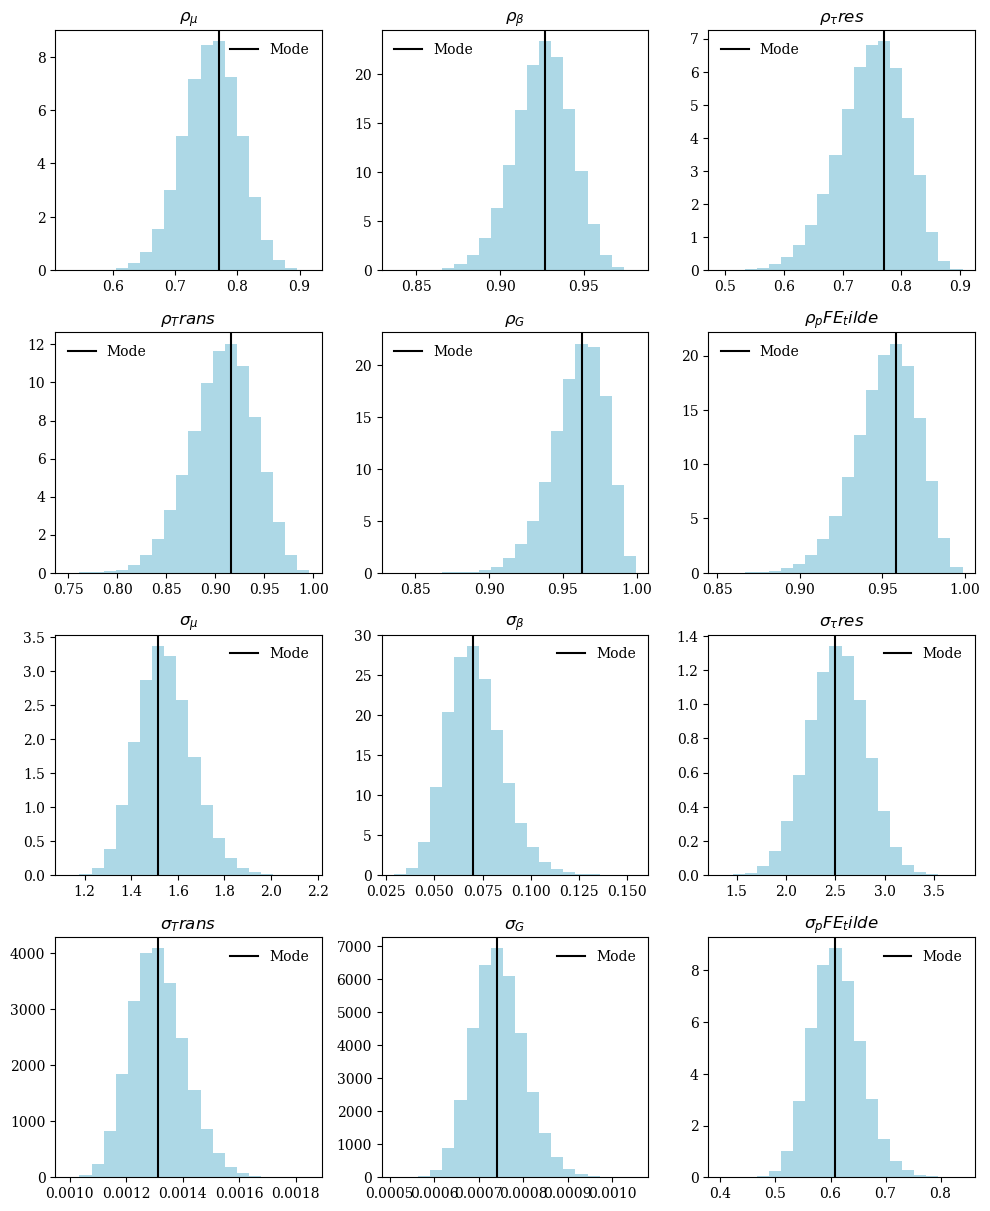

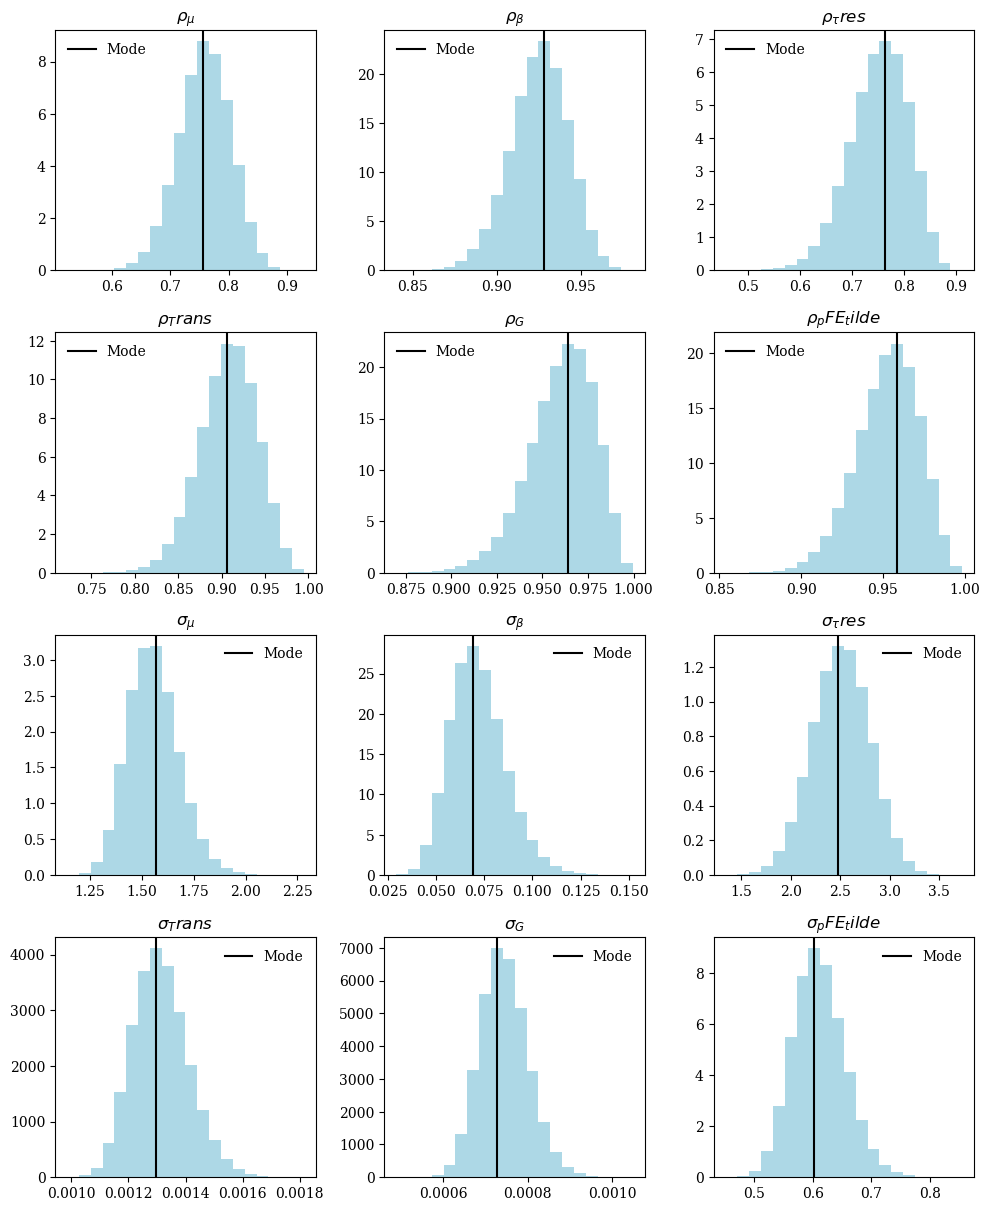

In [50]:
# Plot the sample distribution of accepted draws (posterior)
modes = {}
for i in range(len(nu_vals)):
    modes[i] = est.plot_posterior_sample(accepted[i], colors=['', 'lightblue', '', '', '', '', 'black'], legends=leg, nb_bins=20)

In [51]:
print('------- Table 23: Bayesian estimation (nu=0.9) -------')
# Statistics of the posterior distribution
means_E1 = accepted[0].mean(axis=0)
stds_E1  = accepted[0].std(axis=0)
percentile5_E1 = np.percentile(accepted[0], 5, axis=0)
percentile95_E1 = np.percentile(accepted[0], 95, axis=0)
results_E1 = pd.DataFrame(dict({'Mode': modes[0], 'Mean': means_E1, 'Std': stds_E1, '5th perc.': percentile5_E1, '95th perc.': percentile95_E1}), index=leg)
results_E1

------- Table 23: Bayesian estimation (nu=0.9) -------


,Mode,Mean,Std,5th perc.,95th perc.
$\rho_μ$,0.770038,0.757845,0.044895,0.682019,0.829516
$\rho_β$,0.926912,0.925347,0.016977,0.896178,0.951932
$\rho_τres$,0.770416,0.749778,0.055807,0.651662,0.834550
$\rho_Trans$,0.915817,0.907517,0.032490,0.851058,0.958111
$\rho_G$,0.962708,0.960381,0.017934,0.927838,0.986062
$\rho_pFE_tilde$,0.958448,0.952647,0.018818,0.919187,0.980780
$\sigma_μ$,1.515220,1.545446,0.118583,1.360911,1.749844
$\sigma_β$,0.069815,0.071269,0.014119,0.050099,0.096160
$\sigma_τres$,2.501307,2.517122,0.289788,2.035622,2.989498
$\sigma_Trans$,0.001313,0.001313,0.000096,0.001165,0.001481


In [52]:
print('------- Table 24: Bayesian estimation (nu=0.75) -------')
# Statistics of the posterior distribution
means_E2 = accepted[1].mean(axis=0)
stds_E2  = accepted[1].std(axis=0)
percentile5_E2 = np.percentile(accepted[1], 5, axis=0)
percentile95_E2 = np.percentile(accepted[1], 95, axis=0)
results_E2 = pd.DataFrame(dict({'Mode': modes[1], 'Mean': means_E2, 'Std': stds_E2, '5th perc.': percentile5_E2, '95th perc.': percentile95_E2}), index=leg)
results_E2

------- Table 24: Bayesian estimation (nu=0.75) -------


,Mode,Mean,Std,5th perc.,95th perc.
$\rho_μ$,0.756320,0.758126,0.044861,0.681668,0.829300
$\rho_β$,0.928273,0.925016,0.017138,0.895452,0.951706
$\rho_τres$,0.763954,0.751584,0.055698,0.653744,0.835364
$\rho_Trans$,0.906217,0.907508,0.032646,0.850929,0.958066
$\rho_G$,0.964026,0.960286,0.017940,0.927832,0.986136
$\rho_pFE_tilde$,0.958733,0.952631,0.019030,0.918862,0.981107
$\sigma_μ$,1.567031,1.556224,0.122765,1.368877,1.769180
$\sigma_β$,0.069285,0.071951,0.014374,0.050522,0.097471
$\sigma_τres$,2.476114,2.509106,0.290294,2.028028,2.982233
$\sigma_Trans$,0.001296,0.001314,0.000098,0.001165,0.001484


###### Shock decomposition

In [53]:
ρ_mu_E1, ρ_beta_E1, ρ_Tax_E1, ρ_Trans_E1, ρ_G_E1, ρ_pFE_tilde_E1, σ_mu_E1, σ_beta_E1, σ_Tax_E1, σ_Trans_E1, σ_G, σ_pFE_tilde_E1 = np.array(results_E1.Mode)
ρ_mu_E2, ρ_beta_E2, ρ_Tax_E2, ρ_Trans_E2, ρ_G_E2, ρ_pFE_tilde_E2, σ_mu_E2, σ_beta_E2, σ_Tax_E2, σ_Trans_E2, σ_G, σ_pFE_tilde_E2 = np.array(results_E2.Mode)

In [54]:
data_decomp = pd.read_excel('data_PLF2023.xlsx', index_col=0)
data_decomp = data_decomp.rename(columns={'pFE': 'pFE_tilde'})

In [55]:
data_decomp['Y']   = data_decomp['Y'] * ss['Y'] / 100
data_decomp['G']   = data_decomp['G'] * ss['G'] / 100
data_decomp['TransEXO'] = data_decomp['TransEXO'] * ss['Trans'] / 100
data_decomp['pi']   = data_decomp['pi'] / 100

In [56]:
outputs_info = {'Y': {'label': 'Output', 'color': 'orangered'},
         'pi': {'label': 'Inflation', 'color': 'crimson'},
         'C': {'label': 'Consumption', 'color': 'tab:red'},
         'w': {'label': 'Real wage', 'color': 'black'},
         'r': {'label': 'Real interest rate', 'color': 'darkgrey'},
         'i': {'label': 'Nominal interest rate', 'color': 'slategrey'},
         'L': {'label': 'Hours worked', 'color': 'grey'},
         'Br': {'label': 'Debt-to-GDP ratio', 'color': 'darkblue'},
         'bouclier': {'label': 'Tariff shield', 'color': 'pink'},
         'bouclier_Y': {'label': 'Tariff shield (% GDP)', 'color': 'pink'},
         'bouclier_Yss': {'label': 'Tariff shield (% long-term GDP)', 'color': 'pink'},
         'pFE': {'label': 'Energy price', 'color': 'royalblue'},
         'pFE_tilde': {'label': 'Energy price', 'color': 'royalblue'},
         'pFE_HA': {'label': 'Subsidised energy price', 'color': 'royalblue'},
         'G': {'label': 'Public spending', 'color': 'yellowgreen'},
         'subv': {'label': 'Energy subsidy', 'color': 'skyblue'},
         'TransEXO': {'label': 'Transfers', 'color': 'darkgreen'},
         'incomp': {'label': 'Incompressible consumption', 'color': 'palevioletred'},
         'E': {'label': 'Household energy', 'color': 'red'},
         'YFE': {'label': 'Firm energy', 'color': 'darkred'},
         'piFE': {'label': 'Energy inflation', 'color': 'red'}}

In [57]:
for i in range(len(nu_vals)):
    globals()['inputs_info_E{}'.format(i+1)] = {'beta': {'label': 'Preference', 'color': 'lightpink', 'rho': ρ_beta_E1},
         'Z': {'label': 'TFP', 'color': 'crimson', 'rho': 0.7},
         'mu': {'label': 'Price markup', 'color': 'orange', 'rho': globals()['ρ_mu_E{}'.format(i+1)]},
         'muw': {'label': 'Wage markup', 'color': 'orangered', 'rho': 0.6},
         'pFE_tilde': {'label': 'Energy price', 'color': 'royalblue', 'rho': globals()['ρ_pFE_tilde_E{}'.format(i+1)]},
         'G': {'label': 'Public spending', 'color': 'yellowgreen', 'rho': globals()['ρ_G_E{}'.format(i+1)]},
         'subv': {'label': 'Energy subsidy', 'color': 'skyblue', 'rho': 0.8},
         'Subv': {'label': 'Incompressible consumption', 'color': 'gold', 'rho': 0.8},
         'Subv1': {'label': 'Pure transfers', 'color': 'chocolate', 'rho': 0.8},
         'Subv2': {'label': 'Transfers for bottom 30%', 'color': 'chocolate', 'rho': 0.8},
         'bouclier_Yss': {'label': 'Transfers to households', 'color': 'skyblue', 'rho': 0.8},
         'TransEXO': {'label': 'Transfers', 'color': 'darkgreen', 'rho': globals()['ρ_Trans_E{}'.format(i+1)]},
         'TaxEXO': {'label': 'Measurement error', 'color': 'navajowhite', 'rho': globals()['ρ_Tax_E{}'.format(i+1)]},
         'rstar': {'label': 'Monetary policy', 'color': 'lightgrey', 'rho': 0.4},
         'kappaw': {'label': 'Wage rigidity', 'color': 'lightgrey', 'rho': 0.95},
         'χl': {'label': 'Income tax distortion', 'color': 'yellow', 'rho': 0},
         'χc': {'label': 'Consumption tax distortion', 'color': 'yellow', 'rho': 0}}

In [58]:
pFE_tilde_E1 = (data_decomp['pFE_tilde'] - hist_mean['pFE']) * ss_E1['pFE_tilde'] / 100
pFE_tilde_E2 = (data_decomp['pFE_tilde'] - hist_mean['pFE']) * ss_E2['pFE_tilde'] / 100

In [59]:
# Load the tariff shield size from the benchmark scenario
subv = util.load_result('Results/BenchmarkTariffShield.pickle')

In [60]:
# Tariff shield shock adaptation
shock_adapt = pd.DataFrame([[0.5, 0.6, 0.7, 0.8, 0.9, 1.0], [0.250242708605920, 0.235033161993200, 0.223164073377885, 0.213643842525828, 0.205838001074490, 0.199321713740431]]).T
shock_adapt.columns = ['nu', 'coefficient']
shock_adapt = shock_adapt.set_index('nu')

In [61]:
# Adapt the subventions in the various cases
subv_E1 = shock_adapt.loc[nu_vals[0]].coefficient * subv / 0.2
subv_E2 = np.mean([shock_adapt.loc[0.7].coefficient, shock_adapt.loc[0.8].coefficient]) * subv / 0.2

In [62]:
# Select the shocks and observed variables at play
inputs  = ['G', 'TransEXO', 'TaxEXO', 'mu', 'beta', 'pFE_tilde', 'subv'] # Shocks
outputs = ['Y', 'pi', 'G', 'TransEXO', 'Br', 'pFE_tilde', 'subv'] # Variables

###### Stationarise the data

In [63]:
datas_df = data_decomp[outputs[:-1]]

# Inflation rate
datas_df['pi'] = datas_df['pi'].pct_change().fillna(0)

# Detrend
for elem in ['Y', 'G', 'TransEXO']: 
    datas_df[elem] = remove_trend(datas_df[elem], trend[elem])

# Remove the historical means
datas_df['Br'] = datas_df['Br'] - 4.0

In [64]:
datas_df_E1 = datas_df.copy()
datas_df_E1['pFE_tilde'] = pFE_tilde_E1
datas_df_E1['subv'] = subv_E1

In [65]:
datas_df_E2 = datas_df.copy()
datas_df_E2['pFE_tilde'] = pFE_tilde_E2
datas_df_E2['subv'] = subv_E2

In [66]:
dates = data_decomp.index

###### Shock decomposition

In [67]:
def build_impulses(G, inputs, outputs, T, inputs_info):
    # Parameters of the shocks
    rhos = {}
    sigmas = {}
    for i in range(len(inputs)):
        rhos[inputs[i]] = inputs_info[inputs[i]]['rho']
        sigmas[inputs[i]] = 1
    
    # Initialise
    impulses = {}
    G_new = {}
    for out in outputs:
        s = {}
        for inp in inputs:
            s[inp] = 0
        G_new[out] = s
        
    for inp in inputs:
        own_shock = sigmas[inp] * rhos[inp]**np.arange(T)
        interm = {}
        for out in outputs:
            # Shocks that are inputs and outputs
            if out in inputs:
                if inp == out:
                    interm[out] = np.eye(T) @ own_shock
                    G_new[out][inp] = np.eye(T)
                else:
                    interm[out] = np.zeros(T)
                    G_new[out][inp] = np.zeros((T, T))
            # Other variables
            else:
                if inp in G[out].keys():
                    if type(G[out][inp]) == ssj.classes.sparse_jacobians.SimpleSparse:
                        interm[out] = G[out][inp].matrix(T) @ own_shock
                        G_new[out][inp] = G[out][inp].matrix(T)
                    else:
                        interm[out] = G[out][inp][:T, :T] @ own_shock
                        G_new[out][inp] = G[out][inp][:T, :T]
                else:
                    interm[out] = np.zeros(T)
                    G_new[out][inp] = np.zeros((T, T))
        interm[inp] = own_shock
        impulses[inp] = interm
    return impulses, G_new, rhos, sigmas

In [68]:
Tobs = len(datas_df)
impulses_E1, _, rhos_E1, sigmas_E1 = build_impulses(globals()['G_estim_E1'], inputs, outputs, Tobs, inputs_info_E1)
impulses_E2, _, rhos_E2, sigmas_E2 = build_impulses(globals()['G_estim_E2'], inputs, outputs, Tobs, inputs_info_E2)

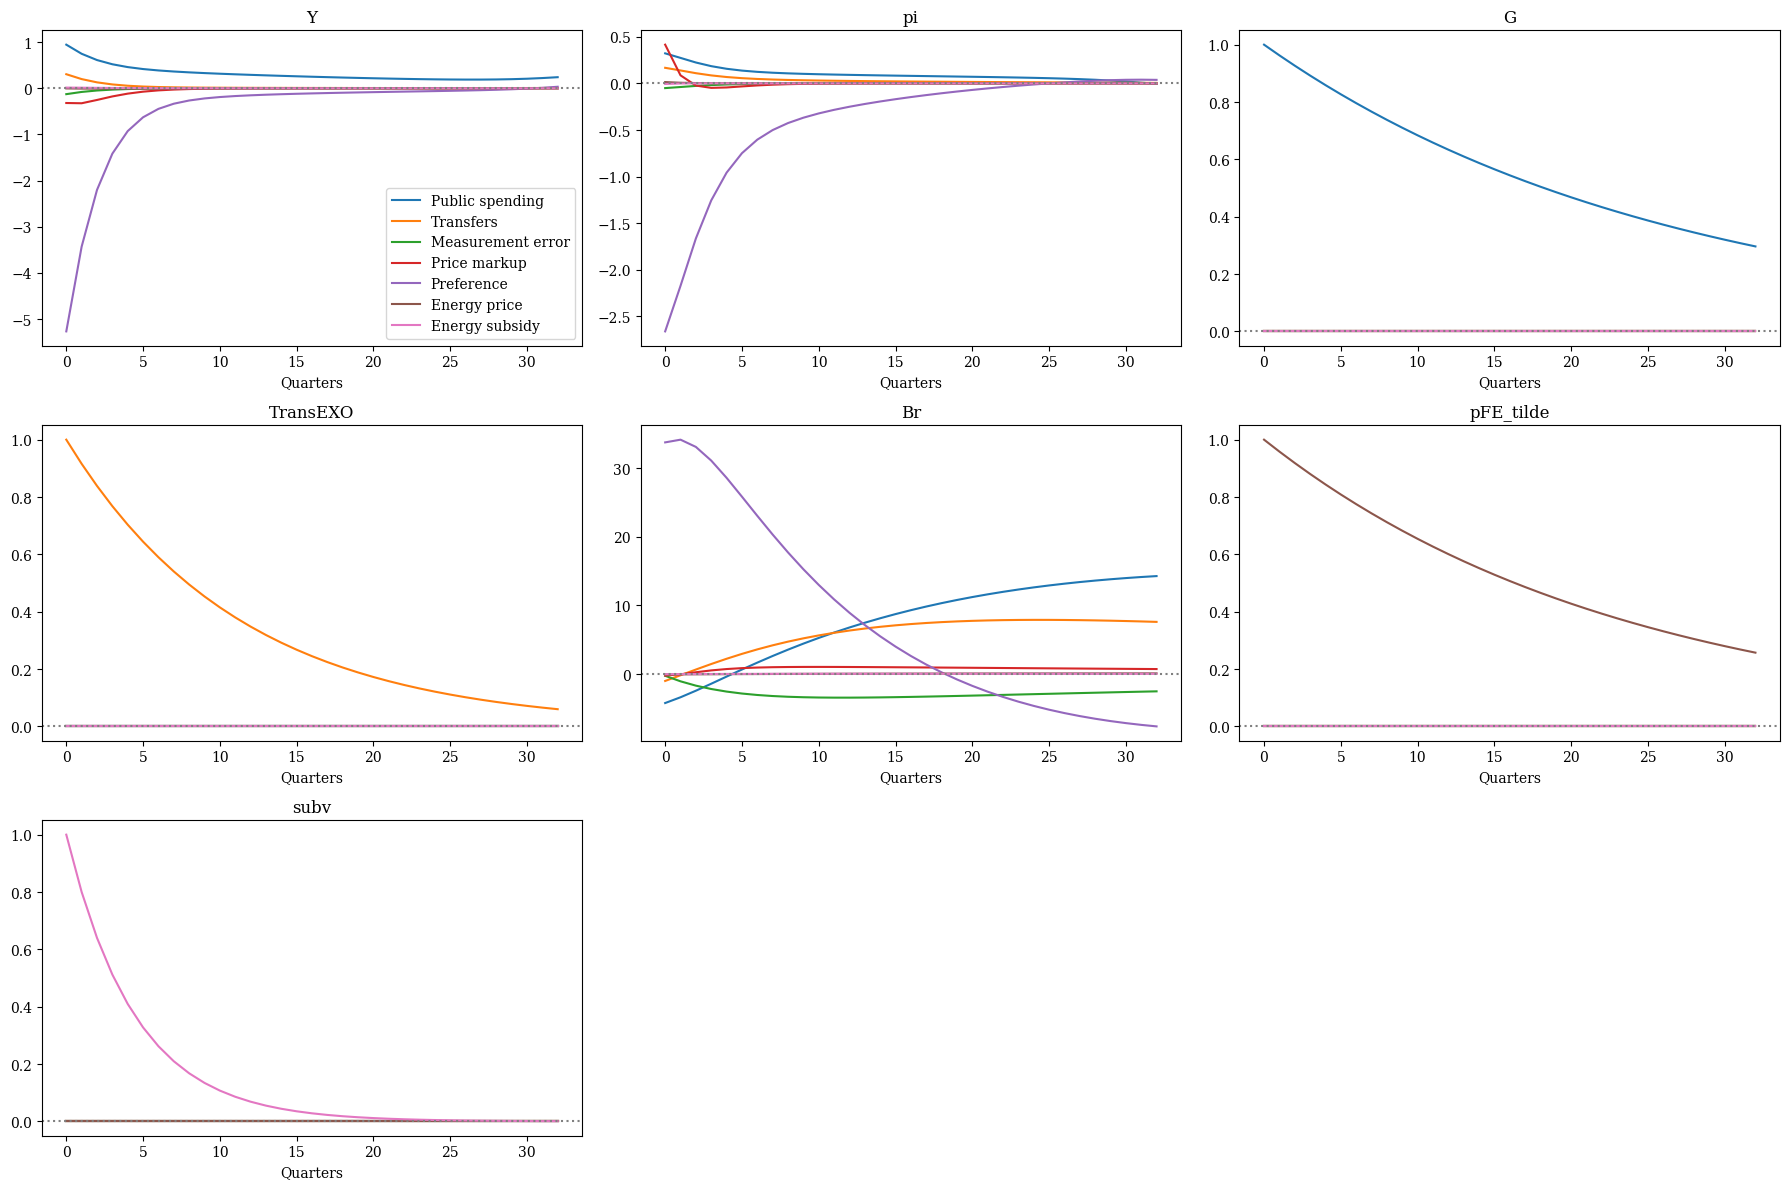

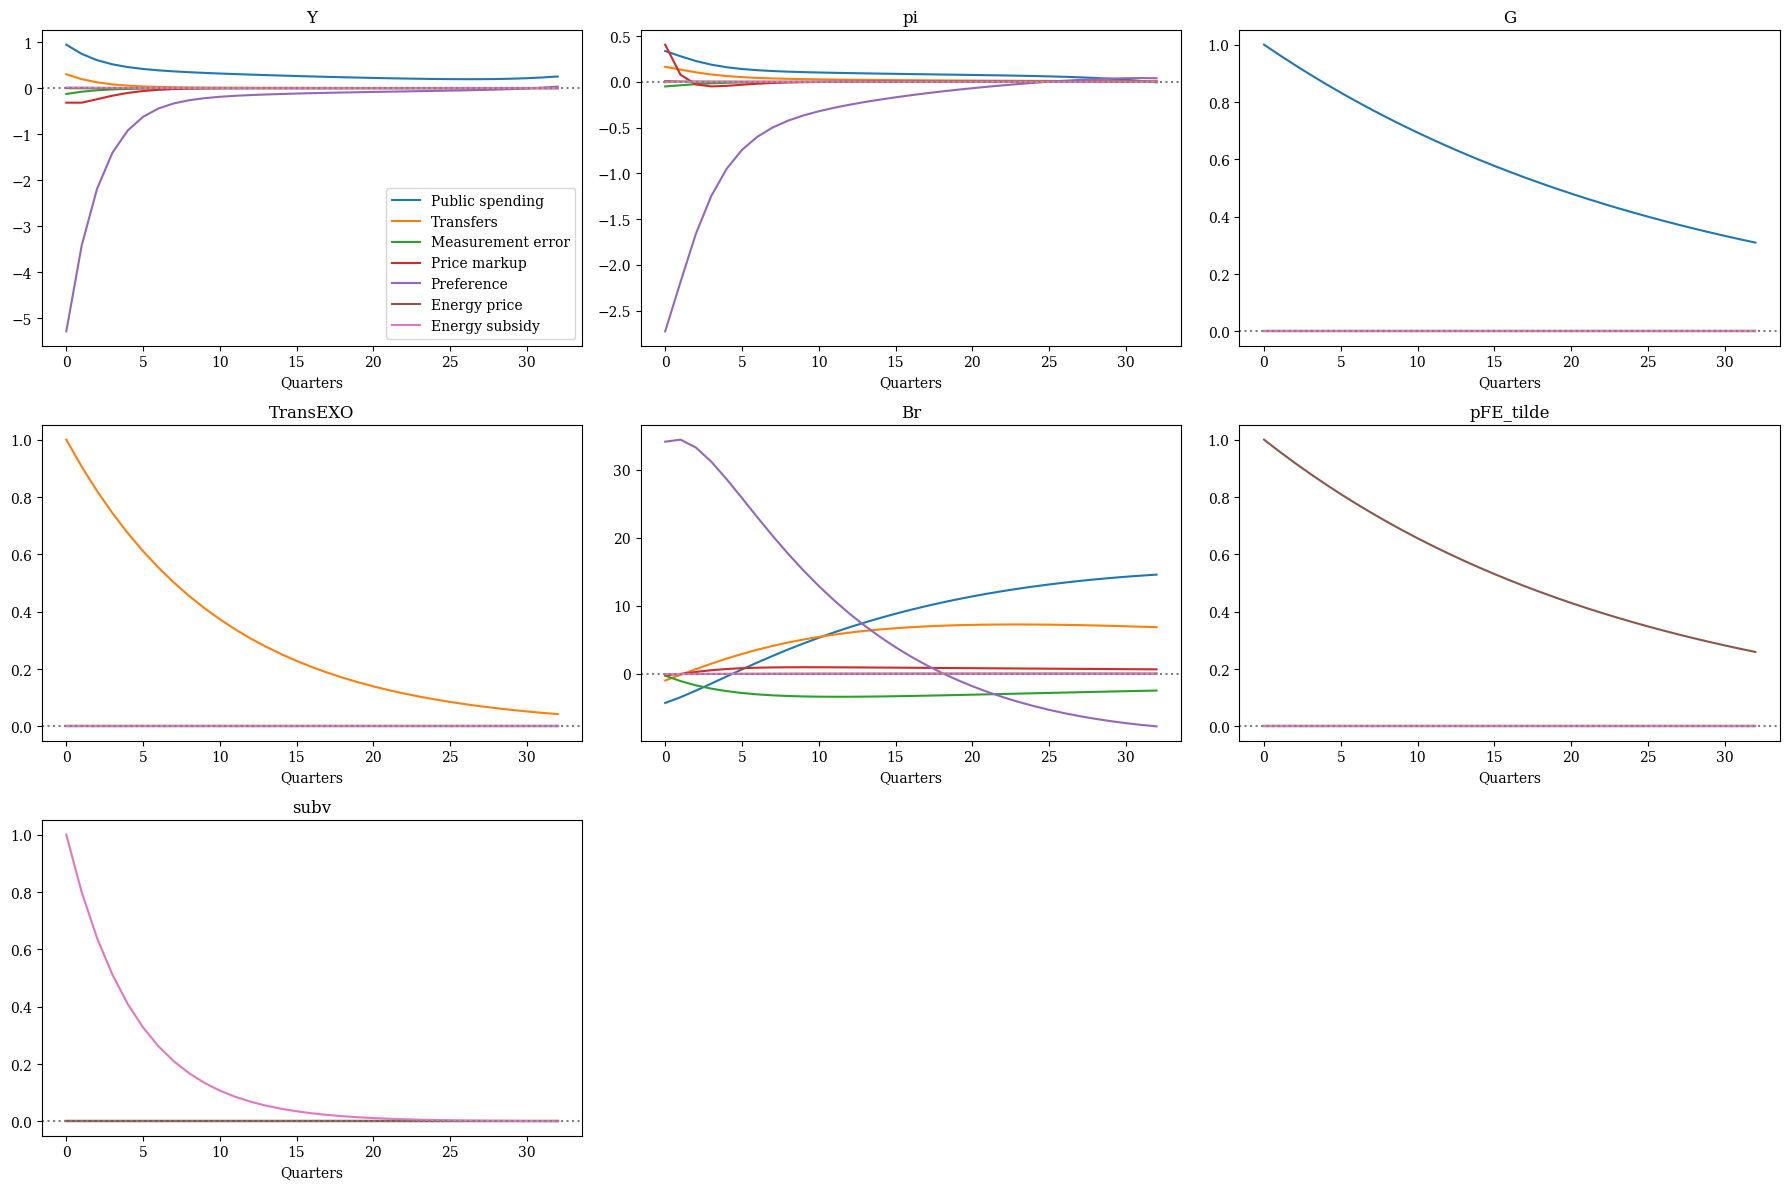

In [69]:
# Check the behaviour of the IRFs prior to the shock decomposition
nb = (len(outputs) // 3) + 1
labels = {}
for elem in inputs_info_E1.keys():
    labels[elem] = inputs_info_E1[elem]['label']
plot_impulses(impulses_E1, labels, outputs, (nb, 3), T=datas_df.shape[0], figsize=(nb*6,12))
plot_impulses(impulses_E2, labels, outputs, (nb, 3), T=datas_df.shape[0], figsize=(nb*6,12))

In [70]:
# Stack the IRFs
M_E1 = np.empty((Tobs, len(outputs), len(inputs)))
M_E2 = np.empty((Tobs, len(outputs), len(inputs)))
for no, o in enumerate(outputs):
    for ns, s in enumerate(inputs):
        M_E1[:, no, ns] = impulses_E1[s][o]
        M_E2[:, no, ns] = impulses_E2[s][o]

In [71]:
datas_df_E1['subv'] = subv_E1
datas_df_E2['subv'] = subv_E2

In [72]:
eps_hat_est_E1, Ds_E1 = back_out_shocks(M_E1, np.array(datas_df_E1), preperiods=0)
# Most probable shocks
eps_hat_est_df_E1 = pd.DataFrame(eps_hat_est_E1, columns=[inputs], index=dates)

In [73]:
eps_hat_est_E2, Ds_E2 = back_out_shocks(M_E2, np.array(datas_df_E2), preperiods=0)
# Most probable shocks
eps_hat_est_df_E2 = pd.DataFrame(eps_hat_est_E2, columns=[inputs], index=dates)

In [74]:
new_outputs = ['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'bouclier_Y', 'bouclier_Yss', 'incomp', 'E', 'YFE', 'pFE', 'pFE_HA']
_, G_E1, _, _ = build_impulses(G_estim_E1, inputs, new_outputs, Tobs, inputs_info_E1)
_, G_E2, _, _ = build_impulses(G_estim_E2, inputs, new_outputs, Tobs, inputs_info_E2)

In [75]:
new_M_E1 = fcst.generate_M(inputs, new_outputs, sigmas_E1, rhos_E1, Tobs, G_E1)
new_Ds_E1 = fcst.reconstruct(new_M_E1, eps_hat_est_E1)

new_M_E2 = fcst.generate_M(inputs, new_outputs, sigmas_E2, rhos_E2, Tobs, G_E2)
new_Ds_E2 = fcst.reconstruct(new_M_E2, eps_hat_est_E2)

In [76]:
for (i, elem) in enumerate(new_outputs):
    globals()['built_%s_E1' % elem] = new_Ds_E1[:, i, :].sum(axis=1)
    globals()['built_%s_E2' % elem] = new_Ds_E2[:, i, :].sum(axis=1)

In [77]:
Y_level_E1   = fcst.rebuild_level(built_Y_E1, 'Output', len(built_Y_E1), g=trend['Y'])
C_level_E1   = fcst.rebuild_level(built_C_E1, 'Consumption', len(built_C_E1), g=trend['Y'])
w_level_E1   = fcst.rebuild_level(built_w_E1, 'Real wages', len(built_w_E1))
L_level_E1   = fcst.rebuild_level(built_L_E1, 'Labor', len(built_L_E1))
r_level_E1   = fcst.rebuild_level(built_r_E1, 'Real rate', None)
i_level_E1   = fcst.rebuild_level(built_i_E1, 'Nominal rate', None)
IPC_level_E1 = fcst.rebuild_level(built_pi_E1, 'Prices', len(built_pi_E1))
Br_level_E1  = fcst.rebuild_level(built_Br_E1, 'Debt-to-GDP ratio', None)
E_level_E1   = fcst.rebuild_level(built_E_E1, 'Energy firm', len(built_E_E1), g=trend['Y'])
YFE_level_E1 = fcst.rebuild_level(built_YFE_E1, 'Energy household', len(built_YFE_E1), g=trend['Y'])
pFE_level_E1 = fcst.rebuild_level(built_pFE_E1, 'Real rate', None)  # TO CHANGE!!!
pFE_HA_level_E1 = fcst.rebuild_level(built_pFE_HA_E1, 'Real rate', None)  # TO CHANGE!!!

level_df_E1  = pd.DataFrame(np.array([Y_level_E1, IPC_level_E1, C_level_E1, w_level_E1, L_level_E1, r_level_E1, i_level_E1, Br_level_E1, E_level_E1, YFE_level_E1, pFE_level_E1, pFE_HA_level_E1]).transpose(), index=datas_df.index,
                       columns=['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE', 'pFE', 'pFE_HA'])

In [78]:
Y_level_E2   = fcst.rebuild_level(built_Y_E2, 'Output', len(built_Y_E2), g=trend['Y'])
C_level_E2   = fcst.rebuild_level(built_C_E2, 'Consumption', len(built_C_E2), g=trend['Y'])
w_level_E2   = fcst.rebuild_level(built_w_E2, 'Real wages', len(built_w_E2))
L_level_E2   = fcst.rebuild_level(built_L_E2, 'Labor', len(built_L_E2))
r_level_E2   = fcst.rebuild_level(built_r_E2, 'Real rate', None)
i_level_E2   = fcst.rebuild_level(built_i_E2, 'Nominal rate', None)
IPC_level_E2 = fcst.rebuild_level(built_pi_E2, 'Prices', len(built_pi_E2))
Br_level_E2  = fcst.rebuild_level(built_Br_E2, 'Debt-to-GDP ratio', None)
E_level_E2   = fcst.rebuild_level(built_E_E2, 'Energy firm', len(built_E_E2), g=trend['Y'])
YFE_level_E2 = fcst.rebuild_level(built_YFE_E2, 'Energy household', len(built_YFE_E2), g=trend['Y'])
pFE_level_E2 = fcst.rebuild_level(built_pFE_E2, 'Real rate', None)  # TO CHANGE!!!
pFE_HA_level_E2 = fcst.rebuild_level(built_pFE_HA_E2, 'Real rate', None)  # TO CHANGE!!!

level_df_E2  = pd.DataFrame(np.array([Y_level_E2, IPC_level_E2, C_level_E2, w_level_E2, L_level_E2, r_level_E2, i_level_E2, Br_level_E2, E_level_E2, YFE_level_E2, pFE_level_E2, pFE_HA_level_E2]).transpose(), index=datas_df.index,
                       columns=['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE', 'pFE', 'pFE_HA'])

###### No tariff shield

In [79]:
# Set subsidy shock to 0
eps_hat_est_nosubv_E1 = eps_hat_est_df_E1.copy()
eps_hat_est_nosubv_E1[['subv']] = 0
Ds_nosubv_E1 = fcst.reconstruct(new_M_E1, np.array(eps_hat_est_nosubv_E1))

eps_hat_est_nosubv_E2 = eps_hat_est_df_E2.copy()
eps_hat_est_nosubv_E2[['subv']] = 0
Ds_nosubv_E2 = fcst.reconstruct(new_M_E2, np.array(eps_hat_est_nosubv_E2))

In [80]:
for (i, elem) in enumerate(new_outputs):
    globals()['built_%s_nosubv_E1' % elem] = Ds_nosubv_E1[:, i, :].sum(axis=1)
    globals()['built_%s_nosubv_E2' % elem] = Ds_nosubv_E2[:, i, :].sum(axis=1)

In [81]:
Y_level_nosubv_E1   = fcst.rebuild_level(built_Y_nosubv_E1, 'Output', len(built_Y_E1), g=trend['Y'])
C_level_nosubv_E1   = fcst.rebuild_level(built_C_nosubv_E1, 'Consumption', len(built_C_E1), g=trend['Y'])
w_level_nosubv_E1   = fcst.rebuild_level(built_w_nosubv_E1, 'Real wages', len(built_w_E1))
L_level_nosubv_E1   = fcst.rebuild_level(built_L_nosubv_E1, 'Labor', len(built_L_E1))
r_level_nosubv_E1   = fcst.rebuild_level(built_r_nosubv_E1, 'Real rate', None)
i_level_nosubv_E1   = fcst.rebuild_level(built_i_nosubv_E1, 'Nominal rate', None)
IPC_level_nosubv_E1 = fcst.rebuild_level(built_pi_nosubv_E1, 'Prices', len(built_pi_E1))
Br_level_nosubv_E1  = fcst.rebuild_level(built_Br_nosubv_E1, 'Debt-to-GDP ratio', None)
E_level_nosubv_E1   = fcst.rebuild_level(built_E_nosubv_E1, 'Energy firm', len(built_E_E1), g=trend['Y'])
YFE_level_nosubv_E1 = fcst.rebuild_level(built_YFE_nosubv_E1, 'Energy household', len(built_YFE_E1), g=trend['Y'])
pFE_level_nosubv_E1 = fcst.rebuild_level(built_pFE_nosubv_E1, 'Real rate', None)  # TO CHANGE!!!
pFE_HA_level_nosubv_E1 = fcst.rebuild_level(built_pFE_HA_nosubv_E1, 'Real rate', None)  # TO CHANGE!!!

level_nosubv_df_E1  = pd.DataFrame(np.array([Y_level_nosubv_E1, IPC_level_nosubv_E1, C_level_nosubv_E1, w_level_nosubv_E1, L_level_nosubv_E1, r_level_nosubv_E1, i_level_nosubv_E1, Br_level_nosubv_E1, E_level_nosubv_E1, YFE_level_nosubv_E1, pFE_level_nosubv_E1, pFE_HA_level_nosubv_E1]).transpose(), index=datas_df.index,
                       columns=['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE', 'pFE', 'pFE_HA'])

In [82]:
Y_level_nosubv_E2   = fcst.rebuild_level(built_Y_nosubv_E2, 'Output', len(built_Y_E2), g=trend['Y'])
C_level_nosubv_E2   = fcst.rebuild_level(built_C_nosubv_E2, 'Consumption', len(built_C_E2), g=trend['Y'])
w_level_nosubv_E2   = fcst.rebuild_level(built_w_nosubv_E2, 'Real wages', len(built_w_E2))
L_level_nosubv_E2   = fcst.rebuild_level(built_L_nosubv_E2, 'Labor', len(built_L_E2))
r_level_nosubv_E2   = fcst.rebuild_level(built_r_nosubv_E2, 'Real rate', None)
i_level_nosubv_E2   = fcst.rebuild_level(built_i_nosubv_E2, 'Nominal rate', None)
IPC_level_nosubv_E2 = fcst.rebuild_level(built_pi_nosubv_E2, 'Prices', len(built_pi_E2))
Br_level_nosubv_E2  = fcst.rebuild_level(built_Br_nosubv_E2, 'Debt-to-GDP ratio', None)
E_level_nosubv_E2   = fcst.rebuild_level(built_E_nosubv_E2, 'Energy firm', len(built_E_E2), g=trend['Y'])
YFE_level_nosubv_E2 = fcst.rebuild_level(built_YFE_nosubv_E2, 'Energy household', len(built_YFE_E2), g=trend['Y'])
pFE_level_nosubv_E2 = fcst.rebuild_level(built_pFE_nosubv_E2, 'Real rate', None)  # TO CHANGE!!!
pFE_HA_level_nosubv_E2 = fcst.rebuild_level(built_pFE_HA_nosubv_E2, 'Real rate', None)  # TO CHANGE!!!

level_nosubv_df_E2  = pd.DataFrame(np.array([Y_level_nosubv_E2, IPC_level_nosubv_E2, C_level_nosubv_E2, w_level_nosubv_E2, L_level_nosubv_E2, r_level_nosubv_E2, i_level_nosubv_E2, Br_level_nosubv_E2, E_level_nosubv_E2, YFE_level_nosubv_E2, pFE_level_nosubv_E2, pFE_HA_level_nosubv_E2]).transpose(), index=datas_df.index,
                       columns=['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE', 'pFE', 'pFE_HA'])

###### Inequalities

In [83]:
varineq = ['C_', 'CTOT_', 'INC_', 'A_']
varineq_names = ['Consumption', 'Consumption (incl. incompressible energy cons.)', 'Net income', 'Wealth']

In [84]:
nS = len(ss_E1.internals['household']['e_grid'])
stats_prod_E1 = pd.DataFrame(np.array([[ss_E1['A_' + str(i)]/ss_E1.internals['household']['pi_e'][i] for i in range(nS)],
                              [ss_E1['C_' + str(i)]/ss_E1.internals['household']['pi_e'][i] for i in range(nS)],
                              [ss_E1['INC_' + str(i)]/ss_E1.internals['household']['pi_e'][i] for i in range(nS)]]).transpose(),
                             columns=['Wealth', 'Consumption', 'Net income'],
                             index=['P' + str(i+1) for i in range(nS)])

In [85]:
nS = len(ss_E2.internals['household']['e_grid'])
stats_prod_E2 = pd.DataFrame(np.array([[ss_E2['A_' + str(i)]/ss_E2.internals['household']['pi_e'][i] for i in range(nS)],
                              [ss_E2['C_' + str(i)]/ss_E2.internals['household']['pi_e'][i] for i in range(nS)],
                              [ss_E2['INC_' + str(i)]/ss_E2.internals['household']['pi_e'][i] for i in range(nS)]]).transpose(),
                             columns=['Wealth', 'Consumption', 'Net income'],
                             index=['P' + str(i+1) for i in range(nS)])

In [86]:
colors = ['blue', '#7692FF', '#C2CEFF', 'black', '#FF9999', '#FF4747', 'red']

In [87]:
ineq_var = ['C', 'INC', 'A']
ineq_outputs = [elem+'_'+str(i) for elem in ineq_var for i in range(7)]
_, G_ineq_E1, _, _ = build_impulses(G_estim_E1, inputs, ineq_outputs, Tobs, inputs_info_E1)
_, G_ineq_E2, _, _ = build_impulses(G_estim_E2, inputs, ineq_outputs, Tobs, inputs_info_E2)

ineq_M_E1  = fcst.generate_M(inputs, ineq_outputs, sigmas_E1, rhos_E1, Tobs, G_ineq_E1)
ineq_Ds_E1 = fcst.reconstruct(ineq_M_E1, eps_hat_est_E1)
ineq_Ds_nosubv_E1 = fcst.reconstruct(ineq_M_E1, np.array(eps_hat_est_nosubv_E1))

ineq_M_E2  = fcst.generate_M(inputs, ineq_outputs, sigmas_E2, rhos_E2, Tobs, G_ineq_E2)
ineq_Ds_E2 = fcst.reconstruct(ineq_M_E2, eps_hat_est_E2)
ineq_Ds_nosubv_E2 = fcst.reconstruct(ineq_M_E2, np.array(eps_hat_est_nosubv_E2))

for elem in ineq_var:
    for i in range(7):
        globals()['built_%s_%s_E1' % (elem, i)] = ineq_Ds_E1[:, i, :].sum(axis=1) / ss_E1[elem + '_' + str(i)]
        globals()['%s_%s_level_E1' % (elem, i)] = fcst.rebuild_level(globals()['built_%s_%s_E1' % (elem, i)], 'Consumption',
                                                                  len(globals()['built_%s_%s_E1' % (elem, i)]))
        globals()['built_%s_%s_nosubv_E1' % (elem, i)] = ineq_Ds_nosubv_E1[:, i, :].sum(axis=1) / ss_E1[elem + '_' + str(i)]
        globals()['%s_%s_level_nosubv_E1' % (elem, i)] = fcst.rebuild_level(globals()['built_%s_%s_nosubv_E1' % (elem, i)], 'Consumption',
                                                                         len(globals()['built_%s_%s_nosubv_E1' % (elem, i)]))
        
        globals()['built_%s_%s_E2' % (elem, i)] = ineq_Ds_E2[:, i, :].sum(axis=1) / ss_E2[elem + '_' + str(i)]
        globals()['%s_%s_level_E2' % (elem, i)] = fcst.rebuild_level(globals()['built_%s_%s_E2' % (elem, i)], 'Consumption',
                                                                  len(globals()['built_%s_%s_E2' % (elem, i)]))
        globals()['built_%s_%s_nosubv_E2' % (elem, i)] = ineq_Ds_nosubv_E2[:, i, :].sum(axis=1) / ss_E2[elem + '_' + str(i)]
        globals()['%s_%s_level_nosubv_E2' % (elem, i)] = fcst.rebuild_level(globals()['built_%s_%s_nosubv_E2' % (elem, i)], 'Consumption',
                                                                         len(globals()['built_%s_%s_nosubv_E2' % (elem, i)]))

In [88]:
ineq_df_E1 = pd.DataFrame(np.array([C_0_level_E1, C_1_level_E1, C_2_level_E1, C_3_level_E1, C_4_level_E1, C_5_level_E1, C_6_level_E1]).transpose(),
                      index=dates, columns=['Consumption P1', 'Consumption P2', 'Consumption P3', 'Consumption P4', 'Consumption P5', 'Consumption P6', 'Consumption P7'])

ineq_df_nosubv_E1 = pd.DataFrame(np.array([C_0_level_nosubv_E1, C_1_level_nosubv_E1, C_2_level_nosubv_E1, C_3_level_nosubv_E1, C_4_level_nosubv_E1, C_5_level_nosubv_E1, C_6_level_nosubv_E1]).transpose(),
                      index=dates, columns=['Consumption P1', 'Consumption P2', 'Consumption P3', 'Consumption P4', 'Consumption P5', 'Consumption P6', 'Consumption P7'])

ineq_df_E2 = pd.DataFrame(np.array([C_0_level_E2, C_1_level_E2, C_2_level_E2, C_3_level_E2, C_4_level_E2, C_5_level_E2, C_6_level_E2]).transpose(),
                      index=dates, columns=['Consumption P1', 'Consumption P2', 'Consumption P3', 'Consumption P4', 'Consumption P5', 'Consumption P6', 'Consumption P7'])

ineq_df_nosubv_E2 = pd.DataFrame(np.array([C_0_level_nosubv_E2, C_1_level_nosubv_E2, C_2_level_nosubv_E2, C_3_level_nosubv_E2, C_4_level_nosubv_E2, C_5_level_nosubv_E2, C_6_level_nosubv_E2]).transpose(),
                      index=dates, columns=['Consumption P1', 'Consumption P2', 'Consumption P3', 'Consumption P4', 'Consumption P5', 'Consumption P6', 'Consumption P7'])

# legend
ll=['Bottom 1.5%', 'Bottom 10%', 'Bottom 33%', 'Middle', 'Top 33%', 'Top 10%','Top 1.5%'] 

In [89]:
level_nosubv_df_E1['year'] = np.floor(level_nosubv_df_E1.index)
print('---- Tables 10 and 11: nu = 0.9 row ----')
debt_2027 = level_nosubv_df_E1.groupby(['year']).mean()[['Br']].iloc[-1]['Br']
print('Debt-to-GDP ratio (in 2027): ', np.round(debt_2027, 1), '%')
GDP_2022 = (100 * level_nosubv_df_E1.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2022.0]['Y']
GDP_2023 = (100 * level_nosubv_df_E1.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2023.0]['Y']
print('2022 GDP growth: ', np.round(GDP_2022, 2), '%')
print('2023 GDP growth: ', np.round(GDP_2023, 2), '%')
inf_2022 = (100 * level_nosubv_df_E1['pi'].pct_change(4).dropna().loc[2022.5])
inf_2023 = (100 * level_nosubv_df_E1['pi'].pct_change(4).dropna().loc[2023.5])
print('2022 inflation: ', np.round(inf_2022, 1), '%')
print('2023 inflation: ', np.round(inf_2023, 1), '%')
ineq_start = ineq_bench = ((built_C_5_E1[9:17]+stats_prod_E1['Consumption'].iloc[5])/(built_C_1_E1[9:17]+stats_prod_E1['Consumption'].iloc[1]))[0]
ineq_bench = ((built_C_5_E1[9:17]+stats_prod_E1['Consumption'].iloc[5])/(built_C_1_E1[9:17]+stats_prod_E1['Consumption'].iloc[1]))[-1]
ineq_alt   = ((built_C_5_nosubv_E1[9:17]+stats_prod_E1['Consumption'].iloc[5])/(built_C_1_nosubv_E1[9:17]+stats_prod_E1['Consumption'].iloc[1]))[-1]
print('Consumption inequalities pre-crisis: ', np.round(ineq_start, 2))
print('Consumption inequalities in 2024 (tariff shield): ', np.round(ineq_bench, 2))
print('Consumption inequalities in 2024 (no tariff shield): ', np.round(ineq_alt, 2))

---- Tables 10 and 11: nu = 0.9 row ----
Debt-to-GDP ratio (in 2027):  111.7 %
2022 GDP growth:  2.1 %
2023 GDP growth:  1.1 %
2022 inflation:  7.0 %
2023 inflation:  3.4 %
Consumption inequalities pre-crisis:  2.03
Consumption inequalities in 2024 (tariff shield):  2.25
Consumption inequalities in 2024 (no tariff shield):  2.27


In [90]:
level_nosubv_df_E2['year'] = np.floor(level_nosubv_df_E2.index)
print('---- Tables 10 and 11: nu = 0.75 row ----')
debt_2027 = level_nosubv_df_E2.groupby(['year']).mean()[['Br']].iloc[-1]['Br']
print('Debt-to-GDP ratio (in 2027): ', np.round(debt_2027, 1), '%')
GDP_2022 = (100 * level_nosubv_df_E2.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2022.0]['Y']
GDP_2023 = (100 * level_nosubv_df_E2.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2023.0]['Y']
print('2022 GDP growth: ', np.round(GDP_2022, 2), '%')
print('2023 GDP growth: ', np.round(GDP_2023, 2), '%')
inf_2022 = (100 * level_nosubv_df_E2['pi'].pct_change(4).dropna().loc[2022.5])
inf_2023 = (100 * level_nosubv_df_E2['pi'].pct_change(4).dropna().loc[2023.5])
print('2022 inflation: ', np.round(inf_2022, 1), '%')
print('2023 inflation: ', np.round(inf_2023, 1), '%')
ineq_start = ineq_bench = ((built_C_5_E2[9:17]+stats_prod_E2['Consumption'].iloc[5])/(built_C_1_E2[9:17]+stats_prod_E2['Consumption'].iloc[1]))[0]
ineq_bench = ((built_C_5_E2[9:17]+stats_prod_E2['Consumption'].iloc[5])/(built_C_1_E2[9:17]+stats_prod_E2['Consumption'].iloc[1]))[-1]
ineq_alt   = ((built_C_5_nosubv_E2[9:17]+stats_prod_E2['Consumption'].iloc[5])/(built_C_1_nosubv_E2[9:17]+stats_prod_E2['Consumption'].iloc[1]))[-1]
print('Consumption inequalities pre-crisis: ', np.round(ineq_start, 2))
print('Consumption inequalities in 2024 (tariff shield): ', np.round(ineq_bench, 2))
print('Consumption inequalities in 2024 (no tariff shield): ', np.round(ineq_alt, 2))

---- Tables 10 and 11: nu = 0.75 row ----
Debt-to-GDP ratio (in 2027):  111.6 %
2022 GDP growth:  2.06 %
2023 GDP growth:  1.12 %
2022 inflation:  6.9 %
2023 inflation:  3.4 %
Consumption inequalities pre-crisis:  2.02
Consumption inequalities in 2024 (tariff shield):  2.24
Consumption inequalities in 2024 (no tariff shield):  2.26


<a id="3-TB"></a>
## 3 Trade balance alternatives

1. [Trade balance and constant foreign debt](#3a-CST)
2. [Trade balance and ad hoc behavior for foreign agents](#3b-adhoc)
3. [IRFs](#3c-IRFs)


<a id="3a-CST"></a>
### 1 Trade balance and constant foreign debt

We add some equations:
- Imports $M_t = p_{FEt} \bar{E}_t$
- Exports $X_t = (1-\omega_t)p_{FEt} \bar{E}_t$
- Trade balance $NX_t = X_t - M_t = -\omega_t p_{FEt} \bar{E}_t$
- CONSTANT Net foreign debt $0 = r_t NFA + NX_t$ $\Rightarrow$ $\omega_t = \frac{r_t NFA}{p_{FEt} \bar{E}_t}$   

Budget constraint of households
$$
(1+\tau_c)\mathcal{C}_t + \mathcal{A}_t = (1+r_t)\mathcal{A}_{t-1} + (1-\tau_l) w_t L_t + \tau_t + d_t - (1+\tau_c)(1-s_H) p_{FE,t} c_{FE} \\
(1+\tau_c)\mathcal{C}_t + (B_t + NFA) = (1+r_t)(B_{t-1} + NFA) + (1-\tau_l) w_t L_t + \tau_t + d_t - (1+\tau_c)(1-s_H) p_{FE,t} c_{FE}
$$
Integarting goods supplies
$$
(1+\tau_c)\mathcal{C}_t + (B_t + NFA) = (1+r_t)(B_{t-1} + NFA) + (1-\tau_l) w_t L_t + \tau_t + (Y_t - p_{Ft} Y_{Ft} - \psi^p_t) - (1+\tau_c)(1-s_H) p_{FE,t} c_{FE} \\
(1+\tau_c)\mathcal{C}_t + (B_t + NFA) = (1+r_t)(B_{t-1} + NFA) + (1-\tau_l) w_t L_t + \tau_t + (Y_t - p_{Ht} Y_{Ht} - (1-s_H) p_{FEt} Y_{FEt} - \psi^p_t) - (1+\tau_c)(1-s_H) p_{FE,t} c_{FE} \\
(1+\tau_c)\mathcal{C}_t + (B_t + NFA) = (1+r_t)(B_{t-1} + NFA) + (1-\tau_l) w_t L_t + \tau_t + (Y_t - w_t L_t - p_{FEt} E_t - (1-s_H) p_{FEt} Y_{FEt} - \psi^p_t) - (1+\tau_c)(1-s_H) p_{FE,t} c_{FE}
$$
Integrating budget constraint of Government and market clearing on energy market
$$
\mathcal{C}_t + \underbrace{(B_t - (1+r_t) B_{t-1} + \tau_l w_t L_t + \tau_c \mathcal{C}_t + \tau_c p_{FEt} c_{FE} - \tau_t -s_H p_{FEt}(Y_{FEt} + (1+\tau_c)c_{FE}))}_{G_t} = r_t NFA + Y_t - p_{FEt}\underbrace{(E_t + Y_{FEt})}_{\bar{E}_t} - p_{FEt} c_{FE} - \psi^p_t \\
\mathcal{C}_t + G_t + \psi^p_t = Y_t + r_t NFA - p_{FEt} \bar{E}_t 
$$
Integrating budget constraint of Foreign country
$$
\mathcal{C}_t + G_t + X_t + p_{FEt} c_{FE} + \psi^p_t = Y_t
$$

The steady state restrictions are:
- Imports $M = p_{FE} \bar{E}$
- Exports $X = (1-\omega) M$
- Trade balance $NX = - p_{FE} \bar{E}$ $\Rightarrow$ $NFA=\omega\frac{p_{FE} \bar{E}}{r}$


#### Steady state.

In [91]:
calibration_tb2 = calibration.copy()
calibration_tb2.update({'omex': 0.9})

In [92]:
@ssj.simple
def market_clearing_tb_ss2(omex,A, B, Esupply, cbar, YFE, E, vphi, w, taul, tauc, C, L, eis, frisch, muw, Y, G, pFE, Tax, r, B_b, B_g, B_t):
    M          = pFE * Esupply # Imports
    X          = omex*M        # Exports
    NX         = X - M         # Trade balance
    NFA        = - NX/r
    asset_mkt  = A - (B + NFA)
    energy_mkt   = Esupply - YFE - E
    labour_mkt   = vphi - w * ((1 - taul)/(1 + tauc)) * (C**(-1/eis)) * (L**(-1/frisch)) / muw
    homegood_mkt = Y - (C + G + X + pFE * cbar)
    balanced_bud = taul * w * L + tauc * (C + pFE * cbar) + Tax - (r * B_b + B_g + B_t) * Y
    X_res        = r * NFA + NX
    return asset_mkt, energy_mkt, labour_mkt, homegood_mkt, balanced_bud, M, X, NX, NFA, X_res

In [93]:
from CepreHANKv1 import equations_ss, definitions_ss

model_tb_ss2 = ssj.create_model(blocks=[household, equations_ss, definitions_ss, market_clearing_tb_ss2], name='CepreHANK with static trade balance steady-state')
# model_tb_ss2.solve_steady_state_options['verbose'] = True
ss_tb2 = model_tb_ss2.solve_steady_state(calibration=calibration_tb2, unknowns=unknowns_ss, targets=targets_ss)

#### Dynamics.

In [94]:
ss_tb2['omexV'] = ss_tb2['omex']

In [95]:
@ssj.simple
def mkt_clearing_tb2(A, B, C, Capprox, G, Y, pFE, adj_p, E, YFE, cbar, r, omex):
    Br         = B / Y
    Esupply    = E + YFE
    M          = pFE * Esupply # Imports
    omexV      = r*ss_tb2['NFA']/M   
    X          = (1-omexV)*M
    NX         = X - M
    asset_mkt  = A - (B + ss_tb2['NFA'])
    homegood_mkt = Y - (C + G + pFE * cbar + adj_p + X)
    conso      = Capprox - C
    incomp     = pFE * cbar
    return asset_mkt, homegood_mkt, Br, conso, incomp, Esupply, NX, M, X, omexV

In [96]:
unknowns_tb2   = ['pi', 'w', 'Y', 'Capprox', 'B']
targets_tb2    = ['nkpc_res', 'asset_mkt', 'labour_mkt', 'conso', 'debt_res']
block_list_tb2 = [subsidy, firm, monetary, fiscal, nkpc, inflation, union, wage, mkt_clearing_tb2, household]
model_tb2      = ssj.create_model(block_list_tb2, name='CepreHANK with static trade balance')

<a id="3b-adhoc"></a>
### 2 Trade balance and ad hoc behaviors for foreign households

The consumption of foreign households is the exportations of the French firms:
$$
X_t = -\nu_b NFA_{t-1} + \nu_m M_t
$$
where $M_t=p_{Et}\bar{E}_t$ is the income of foreign households and $NFA_{t-1}$ is the debt of the foreign househods vis-a-vis of the French households.\\

The budgetary constraint of foreign agents is
$$
NFA_{t} = (1+r_t) NFA_{t-1} + X_t - M_t = (1+r_t-\nu_b) NFA_{t-1} - (1-\nu_m) M_t
$$

At the steady state, the budgetary constraint of foreign agents leads to
$$
(1-\nu_m) M = (1+r-\nu_b) NFA~~~\Rightarrow~~~NFA = \frac{1-\nu_m}{1+r-\nu_b} M
$$

The general equilibrium conditions state that:
Budget constraint of households
$$
(1+\tau_c)\mathcal{C}_t + \mathcal{A}_t = (1+r_t)\mathcal{A}_{t-1} + (1-\tau_l) w_t L_t + \tau_t + d_t - (1+\tau_c)(1-s_H) p_{FE,t} c_{FE} \\
(1+\tau_c)\mathcal{C}_t + (B_t + NFA_t) = (1+r_t)(B_{t-1} + NFA_{t-1}) + (1-\tau_l) w_t L_t + \tau_t + d_t - (1+\tau_c)(1-s_H) p_{FE,t} c_{FE}
$$
Integarting goods supplies
$$
(1+\tau_c)\mathcal{C}_t + (B_t + NFA_t) = (1+r_t)(B_{t-1} + NFA_{t-1}) + (1-\tau_l) w_t L_t + \tau_t + (Y_t - p_{Ft} Y_{Ft} - \psi^p_t) - (1+\tau_c)(1-s_H) p_{FE,t} c_{FE} \\
(1+\tau_c)\mathcal{C}_t + (B_t + NFA_t) = (1+r_t)(B_{t-1} + NFA_{t-1}) + (1-\tau_l) w_t L_t + \tau_t + (Y_t - p_{Ht} Y_{Ht} - (1-s_H) p_{FEt} Y_{FEt} - \psi^p_t) - (1+\tau_c)(1-s_H) p_{FE,t} c_{FE} \\
(1+\tau_c)\mathcal{C}_t + (B_t + NFA_t) = (1+r_t)(B_{t-1} + NFA_{t-1}) + (1-\tau_l) w_t L_t + \tau_t + (Y_t - w_t L_t - p_{FEt} E_t - (1-s_H) p_{FEt} Y_{FEt} - \psi^p_t) - (1+\tau_c)(1-s_H) p_{FE,t} c_{FE}
$$
Integrating budget constraint of Government and market clearing on energy market
$$
\mathcal{C}_t + \underbrace{(B_t - (1+r_t) B_{t-1} + \tau_l w_t L_t + \tau_c \mathcal{C}_t + \tau_c p_{FEt} c_{FE} - \tau_t -s_H p_{FEt}(Y_{FEt} + (1+tau_c)c_{FE}))}_{G_t} = (1+r_t) NFA_{t-1} - NFA_t + Y_t - p_{FEt}\underbrace{(E_t + Y_{FEt})}_{\bar{E}_t}  + p_{FEt}c_{FE} - \psi^p_t \\
\mathcal{C}_t + G_t + \psi^p_t = Y_t + \underbrace{(1+r_t) NFA_{t-1} - NFA_t}_{p_{FEt} \bar{E}_t - X_t} - p_{FEt} \bar{E}_t 
$$
Integrating budget constraint of Foreign country
$$
\mathcal{C}_t + G_t + X_t + + p_{FEt}c_{FE} + \psi^p_t = Y_t
$$

#### Steady state.

In [97]:
calibration_tb3 = calibration.copy()
calibration_tb3.update({'nub': 0.15, 'num': 0.5})

In [98]:
@ssj.simple
def market_clearing_tb_ss3(nub, num, A, B, Esupply, cbar, YFE, E, vphi, w, taul, tauc, C, L, eis, frisch, muw, Y, G, pFE, Tax, r, B_b, B_g, B_t):
    M          = pFE * Esupply         # Imports
    NFA        = ((1-num)/(r-nub))*M   # Debt
    X          = -nub*NFA+num*M        # Exports
    NX         = X - M                 # Trade balance
    asset_mkt  = A - (B + NFA)
    energy_mkt   = Esupply - YFE - E
    labour_mkt   = vphi - w * ((1 - taul)/(1 + tauc)) * (C**(-1/eis)) * (L**(-1/frisch)) / muw
    homegood_mkt = Y - (C + G + X + pFE * cbar)
    balanced_bud = taul * w * L + tauc * (C + pFE * cbar) + Tax - (r * B_b + B_g + B_t) * Y
    X_res        = r * NFA + NX
    return asset_mkt, energy_mkt, labour_mkt, homegood_mkt, balanced_bud, M, X, NX, NFA, X_res

In [99]:
model_tb_ss3 = ssj.create_model(blocks=[household, equations_ss, definitions_ss, market_clearing_tb_ss3], name='CepreHANK with dynamic trade balance steady-state')
# model_tb_ss3.solve_steady_state_options['verbose'] = True
ss_tb3 = model_tb_ss3.solve_steady_state(calibration=calibration_tb3, unknowns=unknowns_ss, targets=targets_ss)

#### Dynamics.

In [100]:
@ssj.solved(unknowns={'NFA': ss_tb3['NFA']}, targets=['NFA_res'])
def tb3(NFA, pFE, E, YFE, cbar, r, nub, num):
    Esupply    = E + YFE
    M          = pFE * Esupply  # Imports
    X          = -nub*NFA+num*M # Exports
    NX         = X - M          # Trade balance
    NFA_res    = NFA - (1 + r - nub)*NFA(-1) - (1-num)*M 
    return NFA_res, Esupply, NX, M, X 

@ssj.simple
def mkt_clearing_tb3(A, B, C, Capprox, G, Y, pFE, adj_p, E, YFE, cbar, X, NFA):
    Br         = B / Y
    asset_mkt  = A - (B + NFA)
    homegood_mkt = Y - (C + G + adj_p + pFE * cbar + X)
    conso      = Capprox - C
    incomp     = pFE * cbar
    return asset_mkt, homegood_mkt, Br, conso, incomp

In [101]:
unknowns_tb3   = ['pi', 'w', 'Y', 'Capprox', 'B']
targets_tb3    = ['nkpc_res', 'asset_mkt', 'labour_mkt', 'conso', 'debt_res']
block_list_tb3 = [subsidy, firm, monetary, fiscal, nkpc, inflation, union, wage, tb3, mkt_clearing_tb3, household]
model_tb3      = ssj.create_model(block_list_tb3, name='CepreHANK with dynamic trade balance')

<a id="3c-IRFs"></a>
### 3 IRFs

In [102]:
dpFE  = irf.shock_generator(ss, 'pFE', rho=.8, p=100/100, T=T, truncated_T=truncated_T, display=False).reshape(T)
dpFE_HA  = irf.shock_generator(ss, 'pFE_HA', rho=.8, p=80/100, T=T, truncated_T=truncated_T, display=False).reshape(T)
dsubv    = dpFE - dpFE_HA


In [103]:
# Linear
irfs      = model.solve_impulse_linear(ss, unknowns=unknowns, targets=targets,
                                  inputs={'pFE': dpFE})
irfs_ts      = model.solve_impulse_linear(ss, unknowns=unknowns, targets=targets,
                                  inputs={'subv': dsubv})

irfs_tb2   = model_tb2.solve_impulse_linear(ss_tb2, unknowns=unknowns, targets=targets,
                                  inputs={'pFE': dpFE})
irfs_ts_tb2  = model_tb2.solve_impulse_linear(ss_tb2, unknowns=unknowns, targets=targets,
                                  inputs={'subv': dsubv})

irfs_tb3    = model_tb3.solve_impulse_linear(ss_tb3, unknowns=unknowns, targets=targets,inputs={'pFE': dpFE})
irfs_ts_tb3 = model_tb3.solve_impulse_linear(ss_tb3, unknowns=unknowns, targets=targets,inputs={'subv': dsubv})

------ Figure 22a: Subsidized energy price ------


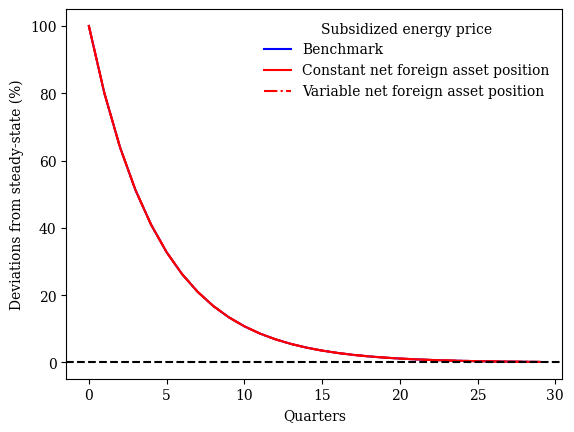

------ Figure 22b: Inflation ------


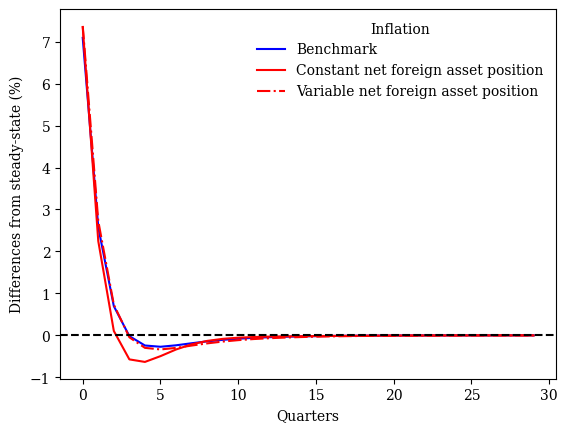

------ Figure 22c: Nominal interest rate ------


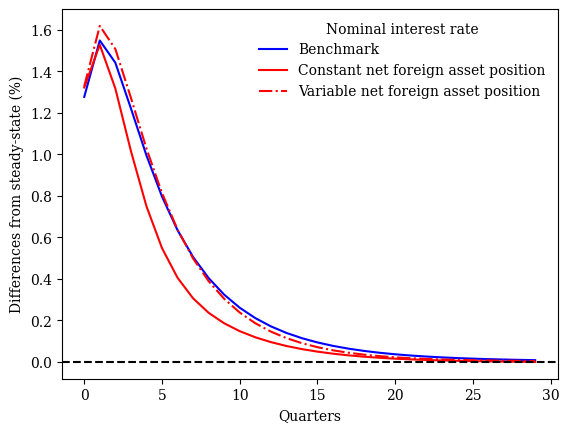

------ Figure 22d: Output ------


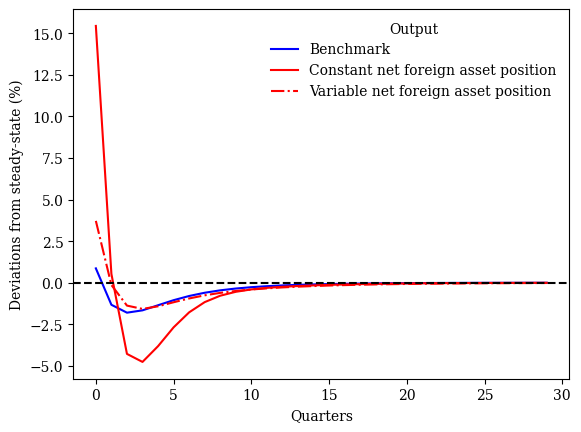

------ Figure 22e: Energy input ------


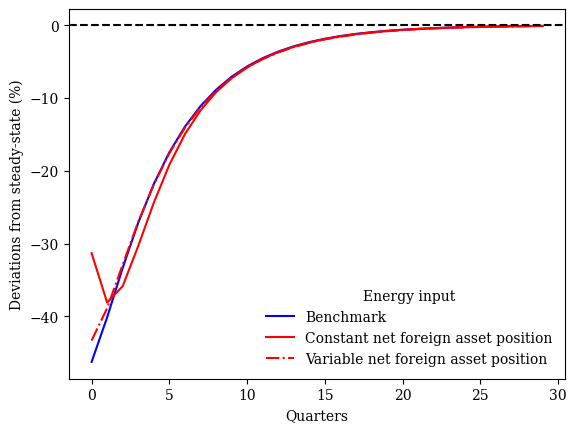

------ Figure 22f: Labor ------


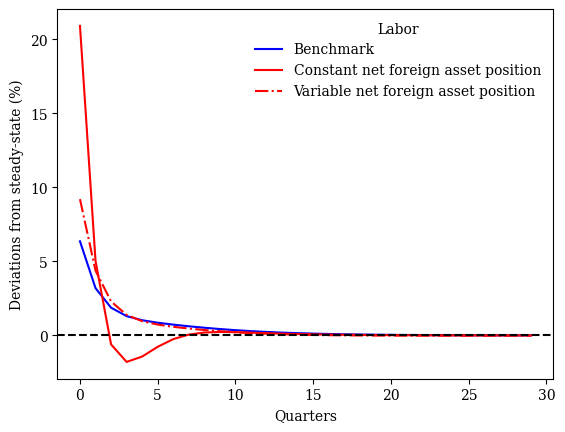

------ Figure 22g: Real wage ------


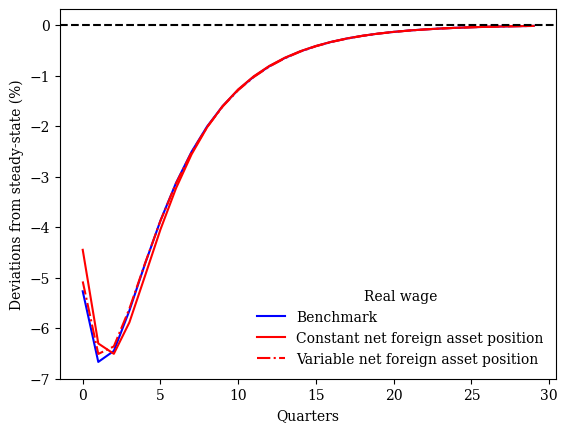

------ Figure 22h: Consumption ------


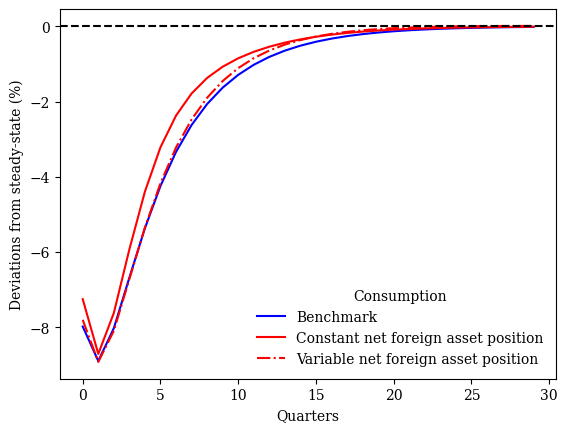

------ Figure 22i: Household energy consumption ------


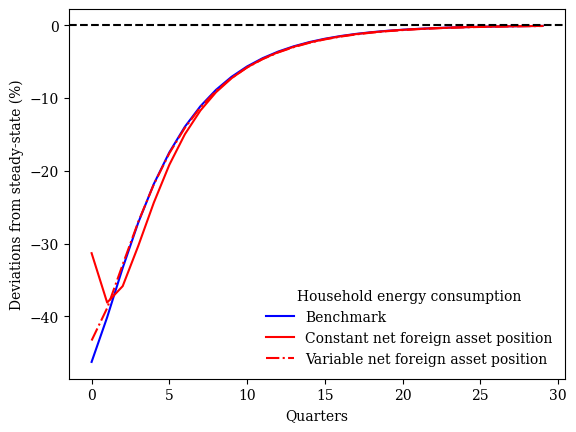

In [104]:
# Figure 22: IRFs (energy shock)
for i in range(len(var)):
    print('------ Figure 22'+string.ascii_lowercase[i]+': '+var_names[i]+' ------')
    if var[i] in ['pi', 'i', 'r']:
        plt.plot(100 * (irfs[var[i]])[:truncated_T], color='blue', label='Benchmark')
        plt.plot(100 * (irfs_tb2[var[i]])[:truncated_T], color='red', label='Constant net foreign asset position')
        plt.plot(100 * (irfs_tb3[var[i]])[:truncated_T], color='red', linestyle='-.', label='Variable net foreign asset position')
        plt.ylabel('Differences from steady-state (%)')
    else:
        plt.plot(100 * (irfs[var[i]] / ss[var[i]])[:truncated_T], color='blue', label='Benchmark')
        plt.plot(100 * (irfs_tb2[var[i]] / ss_tb2[var[i]])[:truncated_T], color='red', label='Constant net foreign asset position')
        plt.plot(100 * (irfs_tb3[var[i]] / ss_tb3[var[i]])[:truncated_T], color='red', linestyle='-.', label='Variable net foreign asset position')
        plt.ylabel('Deviations from steady-state (%)')
    plt.axhline(0, linestyle='--', color='black')
    plt.xlabel('Quarters')
    plt.legend(frameon=False, title=var_names[i])
    if save_fig:
        plt.savefig('Figures/Figure22'+string.ascii_lowercase[i]+'.eps', dpi=500)
    plt.show()

------ Figure 23a: Subsidized energy price ------


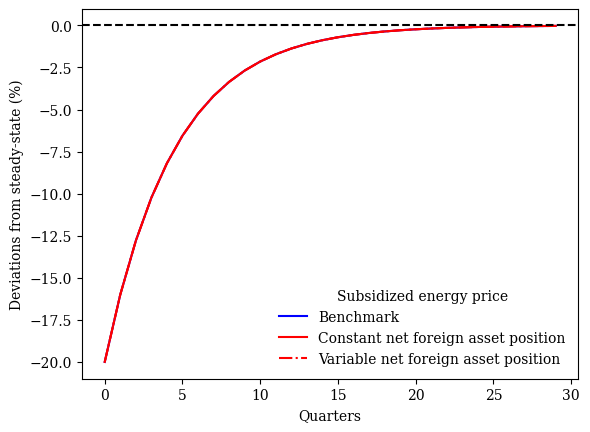

------ Figure 23b: Inflation ------


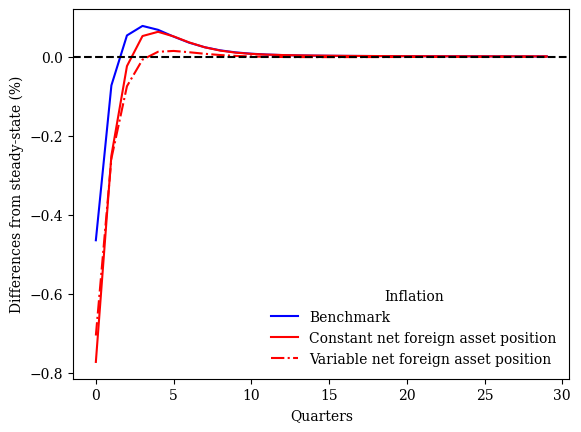

------ Figure 23c: Nominal interest rate ------


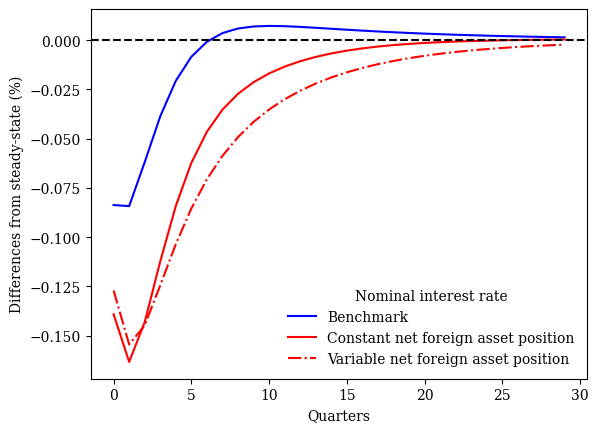

------ Figure 23d: Output ------


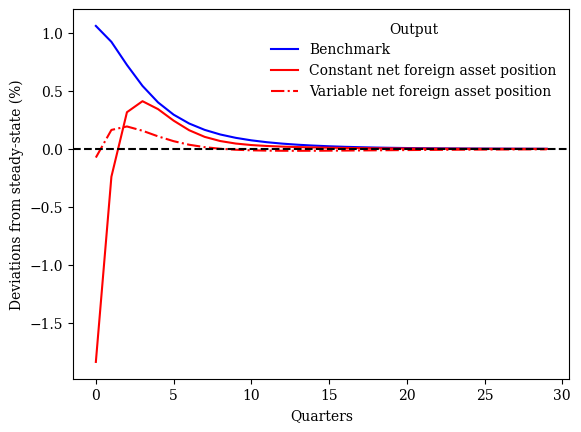

------ Figure 23e: Energy input ------


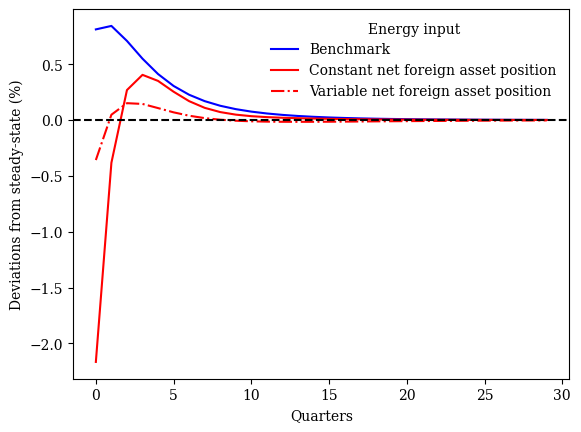

------ Figure 23f: Labor ------


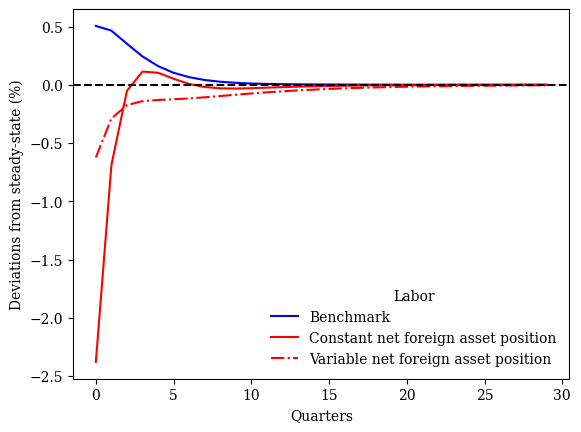

------ Figure 23g: Real wage ------


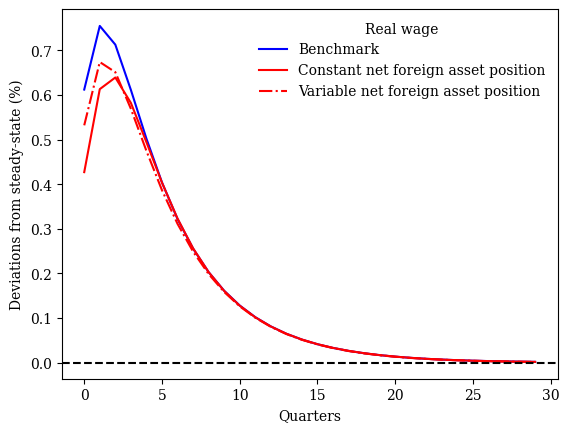

------ Figure 23h: Consumption ------


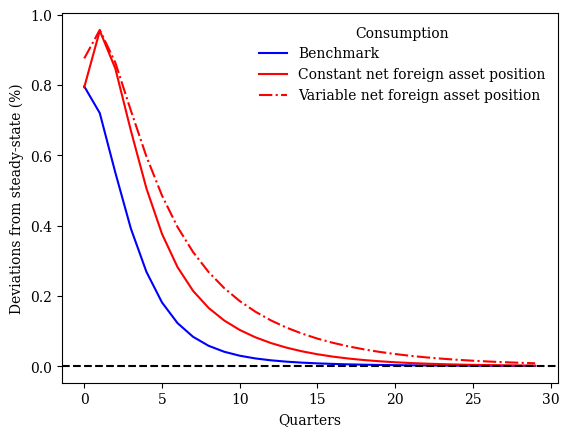

------ Figure 23i: Household energy consumption ------


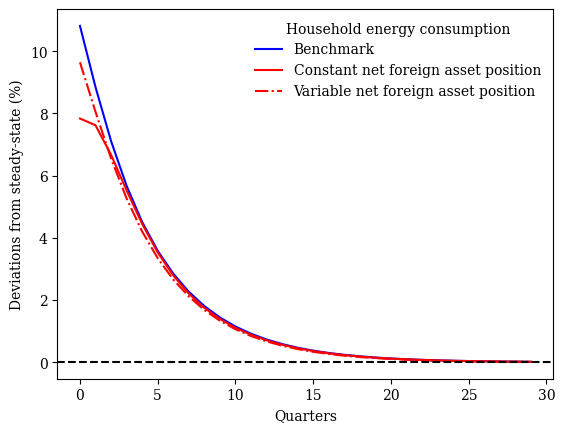

In [105]:
# Figure 23: IRFs (tariff shield shock)
for i in range(len(var)):
    print('------ Figure 23'+string.ascii_lowercase[i]+': '+var_names[i]+' ------')
    if var[i] in ['pi', 'i', 'r']:
        plt.plot(100 * (irfs_ts[var[i]])[:truncated_T], color='blue', label='Benchmark')
        plt.plot(100 * (irfs_ts_tb2[var[i]])[:truncated_T], color='red', label='Constant net foreign asset position')
        plt.plot(100 * (irfs_ts_tb3[var[i]])[:truncated_T], color='red', linestyle='-.', label='Variable net foreign asset position')
        plt.ylabel('Differences from steady-state (%)')
    else:
        plt.plot(100 * (irfs_ts[var[i]] / ss[var[i]])[:truncated_T], color='blue', label='Benchmark')
        plt.plot(100 * (irfs_ts_tb2[var[i]] / ss_tb2[var[i]])[:truncated_T], color='red', label='Constant net foreign asset position')
        plt.plot(100 * (irfs_ts_tb3[var[i]] / ss_tb3[var[i]])[:truncated_T], color='red', linestyle='-.', label='Variable net foreign asset position')
        plt.ylabel('Deviations from steady-state (%)')
    plt.axhline(0, linestyle='--', color='black')
    plt.xlabel('Quarters')
    plt.legend(frameon=False, title=var_names[i])
    if save_fig:
        plt.savefig('Figures/Figure23'+string.ascii_lowercase[i]+'.eps', dpi=500)
    plt.show()